# Project: Machine Learning: Personal Loan Campaign
## AllLife Bank Customer Analysis


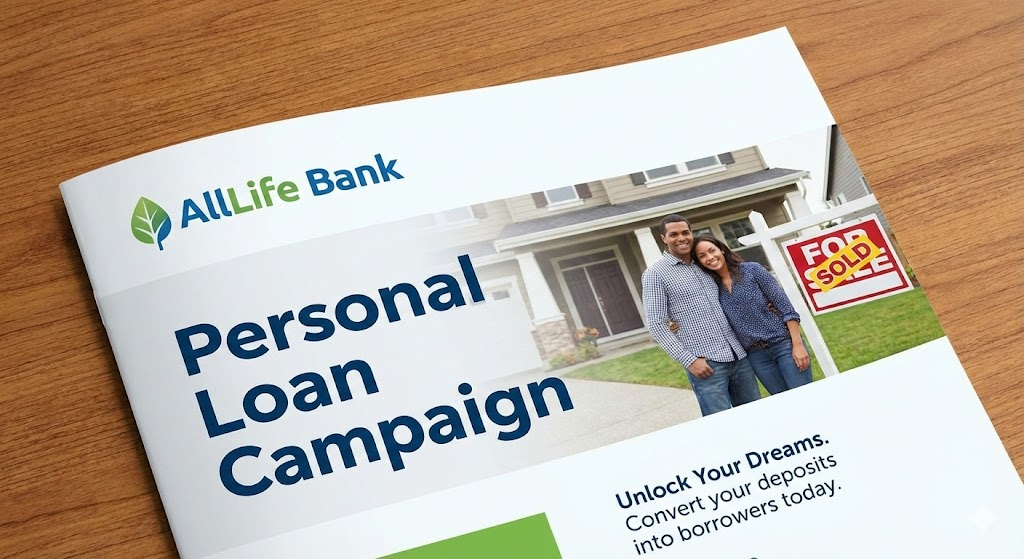

*** *Image generated by Gemini 3 Pro, an AI-powered tool*

### Problem Statement

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are depositors with varying sizes of deposits. The bank aims to increase it's potential loan business by converting a large proportion of it's existing liability customers into personal customers, while continuing to retain them as depositors.

The bank ran a campaign last year for liability customers, shows conversion rate of over 9% success, however the bank wants to improve it's success rate through more targeted and efficient marketing efforts.

### Objective

As a Data Scientist at AllLife Bank, the key objective is to build a predictive model that determines whether a liability customer is likely to buy personal loans, to understand the most significant customer attributes that drive purchases and segment them accordingly.

This model will help the marketing department to identify potential high probability customers for puchasing the loans.


### Data Dictionary

The data contains different attributes of the customers. Detailed description is mentioned below:


| Field | Detail |
| :------- | :------ |
| ID  | Customer ID  |
| Age  | Customer’s age in completed years |
| Experience  | # years of professional experience |
| Income  | Annual income of the customer (in thousand dollars) |
| ZIP Code  | Home Address ZIP code.  |
| Family  | The family size of the customer |
| CCAvg  | Average spending on credit cards per month (in thousand dollars) |
| Education  | Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional  |
| Mortgage  | Value of house mortgage if any. (in thousand dollars)|
| Personal_Loan  | Did this customer accept the personal loan offered in the last campaign?|
| Securities_Account  | Does the customer have a securities account with the bank?|
| CD_Account  | Does the customer have a certificate of deposit (CD) account with the bank?|
| Online  | Do customers use Internet banking facilities?|
| CreditCard  | Does the customer use a credit card issued by any other Bank (excluding All Life Bank)? |


** *Problem statement, objective and data set is provided as part of the project*

### Importing the necessary libraries

In [1]:
# Import warnings package to supress the warnings
import warnings
warnings.filterwarnings("ignore")

# Import all the necessary libraries
# Data Maniputation Libraries
import pandas as pd
import numpy as np

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit on displayed columns
pd.set_option("display.max_columns", None)

# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    make_scorer,
)

### Load the dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df_main = pd.read_csv("/content/drive/MyDrive/PGP Course/Machine Learning/Week 2/Project/Loan_Modelling.csv")

In [4]:
# Copy main data to avoid any changes to original dataset
data = df_main.copy()

### Overview of the dataset

#### View the first and last 5 rows of the dataset

In [5]:
data.head() #By default returns top 5 records

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.60000,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.50000,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.00000,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.70000,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.00000,2,0,0,0,0,0,1


In [6]:
data.tail() #By default returns last 5 records

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.90000,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.40000,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.30000,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.50000,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.80000,1,0,0,0,0,1,1


##### Observations

1. The dataset appears complete with all information provided
2. Based on the data dictionary and project objective, **Personal_Loan** appears to be the target variable (dependent variable) for this predictive modeling task. This binary variable indicates whether a customer accepted the personal loan offered in the last campaign (0 = No, 1 = Yes).
3. Mortgage, Securities_Account, CD_Account, Online and CreditCard variables are binary, and holds either 0 or 1 values


#### Understand the shape of the dataset

In [7]:
data.shape # Get the size and shape of dataset

(5000, 14)

**Observations:**

- The dataset has 5000 rows (customers) and 14 columns (features)

#### Check the data types of the columns for the dataset

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


**Observations:**
1. The dataset contains all numerical columns (13 integer, 1 float)
2. The dataset doesn't have any NULL values
3. From the first 5 records, it is clear that Mortgage, Personal_Loan,  Securities_Account, CD_Account, Online and CreditCard variables are binary, and holds either 0 or 1 values. This suggests one-hot encoding is not needed for these binary categorical variables.
4. ID column is propably an unique identifier.
5. ZIPCode column is defined as numeric, however it also comes under categorical variable. Let's find out how this feature can be treated.
6. Education column can be considered ordinal variable as it holds 1=Undergrad, 2=Grad, 3=Professional

#### Check for missing values

In [9]:
# checking for null values
data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


NOTE: There are no NULL/missing values, which confirms our previous analysis based on info()

#### Verify duplicate values

In [10]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

##### Observations:

There are no duplicates in the data set

#### Dropping the columns with all unique values

In [11]:
data.ID.nunique()

5000

In [12]:
# Drop the 'ID' column as it is a unique identifier with no predictive power.

data = data.drop(["ID"], axis=1)

##### Observations:

1. ID column has 5000 unique values (same as total rows)
2. This confirms ID is a unique identifier with no duplicates
3. ID column can be dropped as it doesn't provide predictive value for the model

#### Statistical summary of the data

**Let's check the statistical summary of the data.**

In [13]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.00000,45.33840,11.46317,23.00000,35.00000,45.00000,55.00000,67.00000
Experience,5000.00000,20.10460,11.46795,-3.00000,10.00000,20.00000,30.00000,43.00000
Income,5000.00000,73.77420,46.03373,8.00000,39.00000,64.00000,98.00000,224.00000
ZIPCode,5000.00000,93169.25700,1759.45509,90005.00000,91911.00000,93437.00000,94608.00000,96651.00000
Family,5000.00000,2.39640,1.14766,1.00000,1.00000,2.00000,3.00000,4.00000
CCAvg,5000.00000,1.93794,1.74766,0.00000,0.70000,1.50000,2.50000,10.00000
Education,5000.00000,1.88100,0.83987,1.00000,1.00000,2.00000,3.00000,3.00000
Mortgage,5000.00000,56.49880,101.71380,0.00000,0.00000,0.00000,101.00000,635.00000
Personal_Loan,5000.00000,0.09600,0.29462,0.00000,0.00000,0.00000,0.00000,1.00000
Securities_Account,5000.00000,0.10440,0.30581,0.00000,0.00000,0.00000,0.00000,1.00000


##### Observations:

1. The Data set now contains 13 columns after dropping ID column.
2. Minimum age of customers is around 23, averaging around 45 years
3. Experience has some negative values detected, as minimum shows -3, this can be because of data quality issues. Average is around 20 years
4. Income has a lot of variation, where minimum is ~8 (thousand dollars) and maximum is around 224. This suggests right skewed distribution.
5. Education feature suggests median of around ~1.88 (However this is an ordinal variable, can be categorically analysed further)
6. The dataset shows around 90% of customers did not accept personal loans (Personal_Loan = 0), while only ~10% accepted (Personal_Loan = 1). This is evident from the distribution where min, 25th percentile, 50th percentile (median), and 75th percentile are all 0, with only the maximum value being 1.

### Data Preprocessing


#### Feature Engineering

1. ZIP Code is a categorical identifier that usually represents geographic regions rather than a numerical quantity. Let's treat the column to handle the feature well.
2. Experience shows negative values which indicates data quality issues

#### Treating ZIP Code

Categorizing based on numerical values for ZIP Code is incorrect because the numeric order holds no mathematical meaning in this context.

To extract meaningful insights for the marketing campaign, let's treat ZIP code first with the help of uszipcode library. It offers below appropriate lookups for address:

- major_city
- post_office_city
- common_city_list
- county
- state

Among these, major_city and county seems to be appropriate fields, although 'County' offers broader grouping, Major City provides the specific locality insights that might be required for the segmented marketing rollouts.

Therefore, we will map ZIP codes to their corresponding Major City and analyze the relationship between City and the target variable, also to understand the importance of this feature for model building.


In [14]:
#Install uszipcode library

!pip install sqlalchemy_mate==2.0.0.0
!pip install uszipcode

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 3.6 MB/s eta 0:00:00
  Created wheel for atomicwrites: filename=atomicwrites-1.4.1-py2.py3-none-any.whl size=6943 sha256=c090510ae47561f6f14a3caceda86c409b03810e17a2577d3c4dc1bb573d9792
  Stored in directory: /root/.cache/pip/wheels/6b/37/a4/ae30755673c2d1e07228f13b4491fcaef62438f771d5012d07
Successfully built atomicwrites


In [15]:
# import SearchEngine from uszipcode
from uszipcode import SearchEngine

# Initialize search engine
search = SearchEngine()

# Function to search by zipcode and return major city
def zipcode_to_city(zipcode):
    try:
        result = search.by_zipcode(str(zipcode))
        return result.major_city
    except:
        return None

# Create a new column 'City' and invoke zipcode_to_city function to get major cities associated with zipcodes

data["City"] = data["ZIPCode"].apply(zipcode_to_city)

Download /root/.uszipcode/simple_db.sqlite from https://github.com/MacHu-GWU/uszipcode-project/releases/download/1.0.1.db/simple_db.sqlite ...
  1.00 MB downloaded ...
  2.00 MB downloaded ...
  3.00 MB downloaded ...
  4.00 MB downloaded ...
  5.00 MB downloaded ...
  6.00 MB downloaded ...
  7.00 MB downloaded ...
  8.00 MB downloaded ...
  9.00 MB downloaded ...
  10.00 MB downloaded ...
  11.00 MB downloaded ...
  Complete!


**Observations**:

1. uszipcode is installed and SearchEngine is initialised.
2. A new column City is created which holds the major city in which the zip code belongs to.
3. This makes it easy for prediction, and helps to perform analysis on categorical values

##### Check the dataset info

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   ZIPCode             5000 non-null   int64  
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal_Loan       5000 non-null   int64  
 9   Securities_Account  5000 non-null   int64  
 10  CD_Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
 13  City                4966 non-null   object 
dtypes: float64(1), int64(12), object(1)
memory usage: 547.0+ KB


In [17]:
data['City'].isnull().sum()

np.int64(34)

**Observations:**

1. New 'City' column has around 34 null records
2. These occur when the ZIP code lookup fails or returns no city information. We need to handle these missing values before using City in analysis or modeling.

##### Missing Value treatment

In [18]:
# Drop ZIPCode column, since we will not use this in our analysis
data.drop('ZIPCode', axis=1, inplace=True)

# Fill Null values with Unknown
data['City'].fillna('Unknown', inplace=True)

#Check the null values in City column
data['City'].isnull().sum()

np.int64(0)

**Observations:**

1. 34 rows out of 5000 (around 0.68% of data) has null values for City
2. Replacing Nulls with Unknown suggests a new 'Unknown' category.
3. Treating with Unknown remains simple and easily interpretable for further analysis

#### Treat Negative Experience values

Experience feature has negative values, which is identified from the dataset statistics. Let's treat these negative values, since logically experience of a customer cannot be negative.

In [19]:
# Check negative experience rows count

(data['Experience'] < 0).sum()

np.int64(52)

There are around 52 records that have negative experience.

In [20]:
# Get the customer's age who has negative experiences

ages_with_neg_exp = data[data['Experience'] < 0]['Age']
print('Minumum age for negative experience', ages_with_neg_exp.min())
print('Maximum age for negative experience', ages_with_neg_exp.max())

Minumum age for negative experience 23
Maximum age for negative experience 29


The above stats suggest that the young customers aged between 23 and 29 have negative experience.

In [21]:
# Convert negative experience values to ZERO

data.loc[data['Experience'] < 0, 'Experience'] = 0

(data['Experience'] < 0).sum()

np.int64(0)

**NOTE:**

Negative experience is invalid, hence replacing the values with 0 (ZERO) would ideally suggest 'no experience' and it's reasonable for young customers.

### Exploratory Data Analysis

#### Univariate Analysis

Numerical Variables:

* Age
* Experience
* Income
* Family
* CCAvg
* Mortgage
* Education (Ordinal)

Binary Categorical variables:

* Personal_Loan
* Securities_Account
* CD_Account
* Online
* CreditCard

Nominal Categorical Variable:

* City

NOTE: Though the data type of categorical variables is defined as Integer, since most of the variables hold either true or false, depicted as 0 or 1, the respective features can be considered as categorical variables for our analysis.


#### Plot Histogram for Numeric Variables

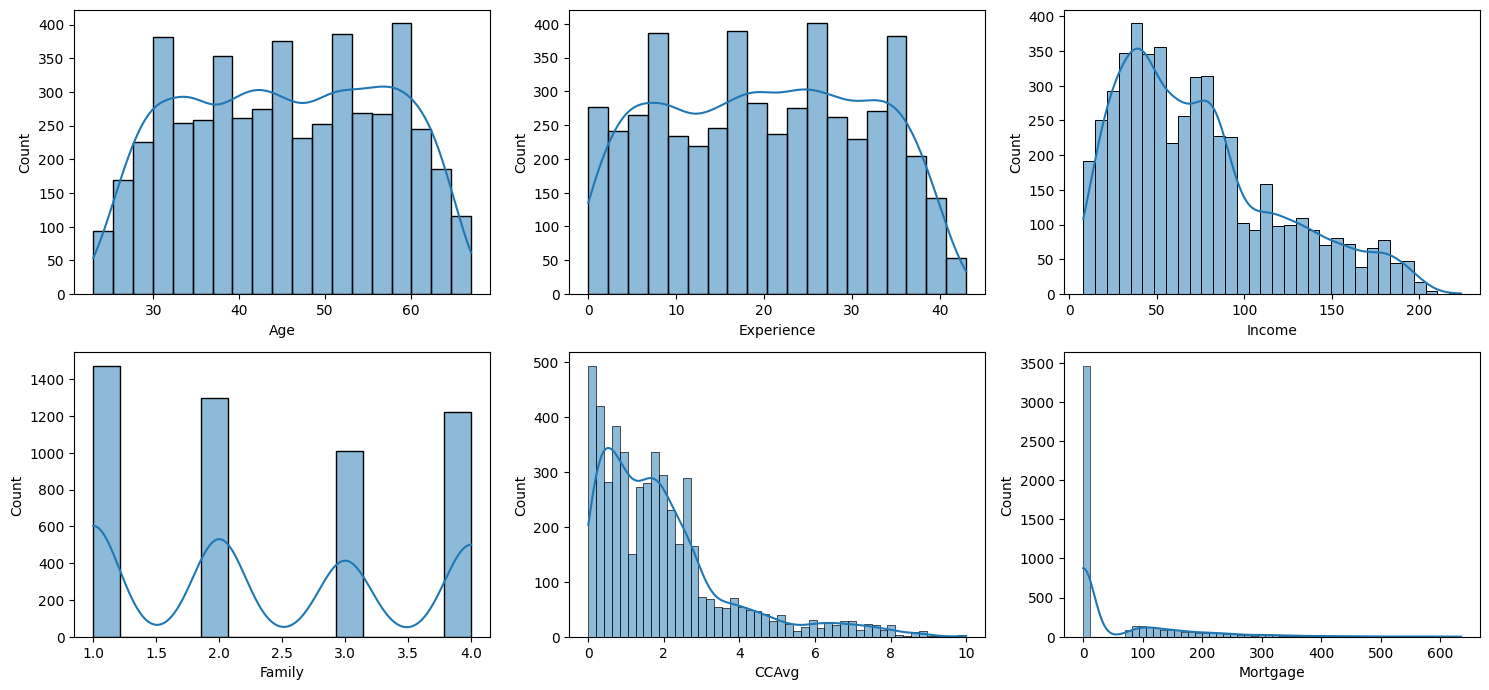

In [22]:
# Define the figure size
plt.figure(figsize=(15, 10))

# Define the list of numerical features
num_features = ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Mortgage'] # Since Education is an Ordinal variable - let's check count plot for this feature

# Plot the histogram for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot (3 per row)
    sns.histplot(data=data, x=feature, kde=True)    # plot the histogram

plt.tight_layout();   # Adds spacing between plots

**Observations from Histogram Plots:**

- **Age**:
  - Approximately normal distribution, averaging around 40-50 years
  - Range from ~23 to ~67 years
  - Most of the customers seems to be middle-aged

- **Experience**:
  - Similar distribution pattern to Age, looks likely normal
  - Range from 0 to ~43 years
  - Peak count is around ~23 years of experience

- **Income**:
  - Plot suggests rightly-skewed distribution
  - Range from ~8K to ~224K (thousand dollars)
  - Majority of customers have income less than $100K
  - Mean income (~73K) is higher than median due to right skewness

- **Family**:
  - Discrete distribution with distinct peaks at 1, 2, 3, and 4 family members
  - Relatively uniform distribution across various family sizes
  - Well-contained within expected range (1-4)

- **CCAvg** (Credit Card Average Spending):
  - Plot suggests rightly-skewed distribution - most customers have low credit card spending
  - Range from 0 to ~10K (thousand dollars per month)
  - Majority spend less than \$3K/month on credit cards

- **Mortgage**:
  - **Highly skewed distribution** with many zeros (customers without mortgages)
  - Range from 0 to ~\$635K (thousand dollars)
  - Majority of customers have no mortgage (0 value)
  - Few customers have very high mortgages ( more than \$400K )




**Key Insights:**
- Most features show right-skewed distributions
- Income and CCAvg distribution plots suggest good candidates for segmentation by spending/income levels
- Mortgage distribution shows many customers are mortgage-free, which may impact loan needs


#### Plot Boxplot for Numeric features

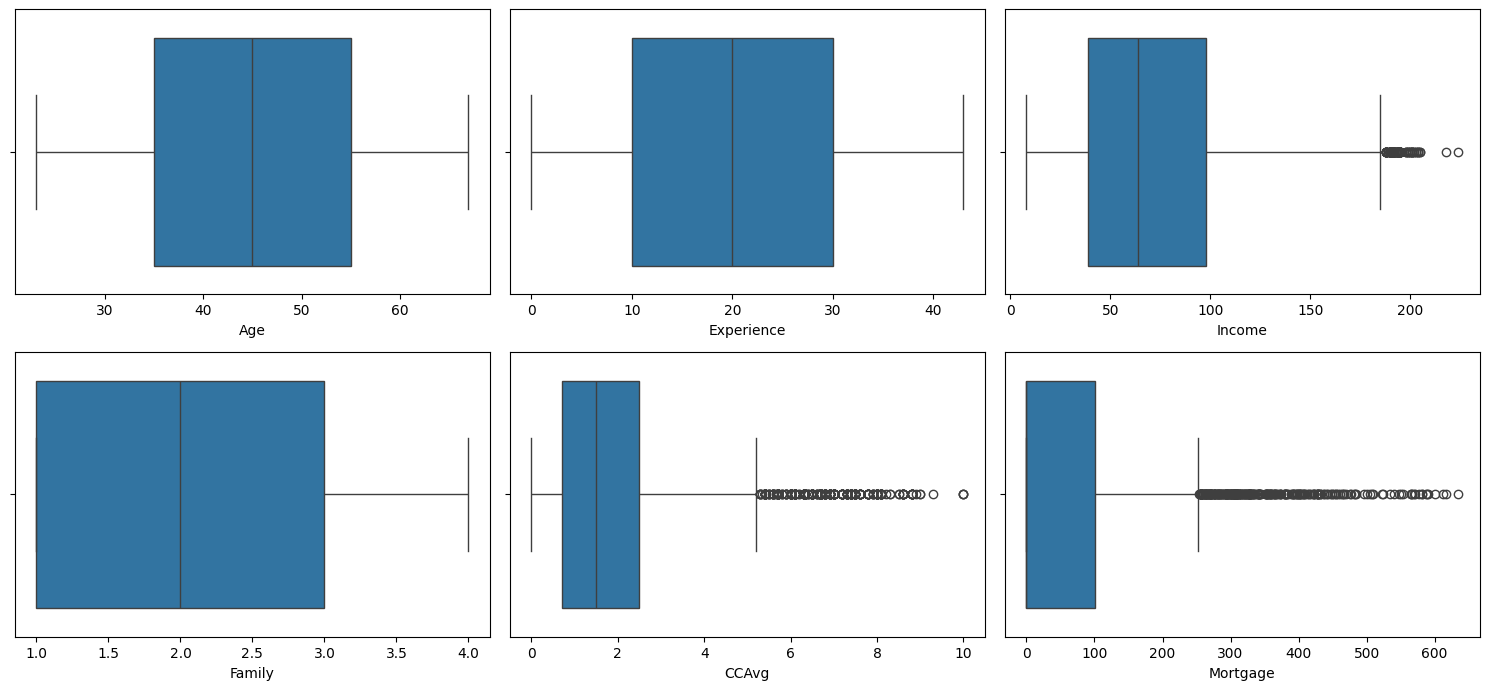

In [23]:
# Define the figure size
plt.figure(figsize=(15, 10))

# Plot the histogram for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot (3 per row)
    sns.boxplot(data=data, x=feature)    # plot the boxplot

plt.tight_layout();   # Adds spacing between plots

**Observations from Box Plots:**

- **Age & Experience**:
  - Confirms normal distribution of the dataset
  - Interquartile range (IQR) shows most customers are between 35-55 years old
  - Interquartile range (IQR) shows most customers have 10 to 30 years of professional experience
  - No significant outliers
  - Median value of age is around ~45 years, while median of professional experience is around 20 years


- **Income**:
  - IQR shows most customers earn between \$40K-\$100K
  - Long whiskers indicate wide income spread, shows right-skewed distribution
  - Quite a few outliers are identified, shows legitimate high earners
  - Median value is around 64K of income

- **Family**:
  - **No significant outliers** - well-contained within 1-4 range
  - It shows uniform distribution across family sizes
  - Median around 2 family members

- **CCAvg** (Credit Card Average Spending):
  - There are many high spending outliers indicates potential high value customers
  - IQR shows most customers spend between 0.5-2.5
  - Median is around 0.8 and shows righly-skewed distribution

- **Mortgage**:
  - Many outliers are detected crossing 250k, indicates lot of customers have high mortgages
  - Median is around 0 indicates most of the customers doesn't have mortgages, and it shows strongly right skewed distribution.

**Outliers**

- Outliers are identified for Income, CCAvg, Mortgage
- However, let's not treat them as they have proper values

#### Count plot for binary categorical variables

Personal_Loan
0   90.40000
1    9.60000
Name: proportion, dtype: float64 

Securities_Account
0   89.56000
1   10.44000
Name: proportion, dtype: float64 

CD_Account
0   93.96000
1    6.04000
Name: proportion, dtype: float64 

Online
1   59.68000
0   40.32000
Name: proportion, dtype: float64 

CreditCard
0   70.60000
1   29.40000
Name: proportion, dtype: float64 

Education
1   41.92000
3   30.02000
2   28.06000
Name: proportion, dtype: float64 



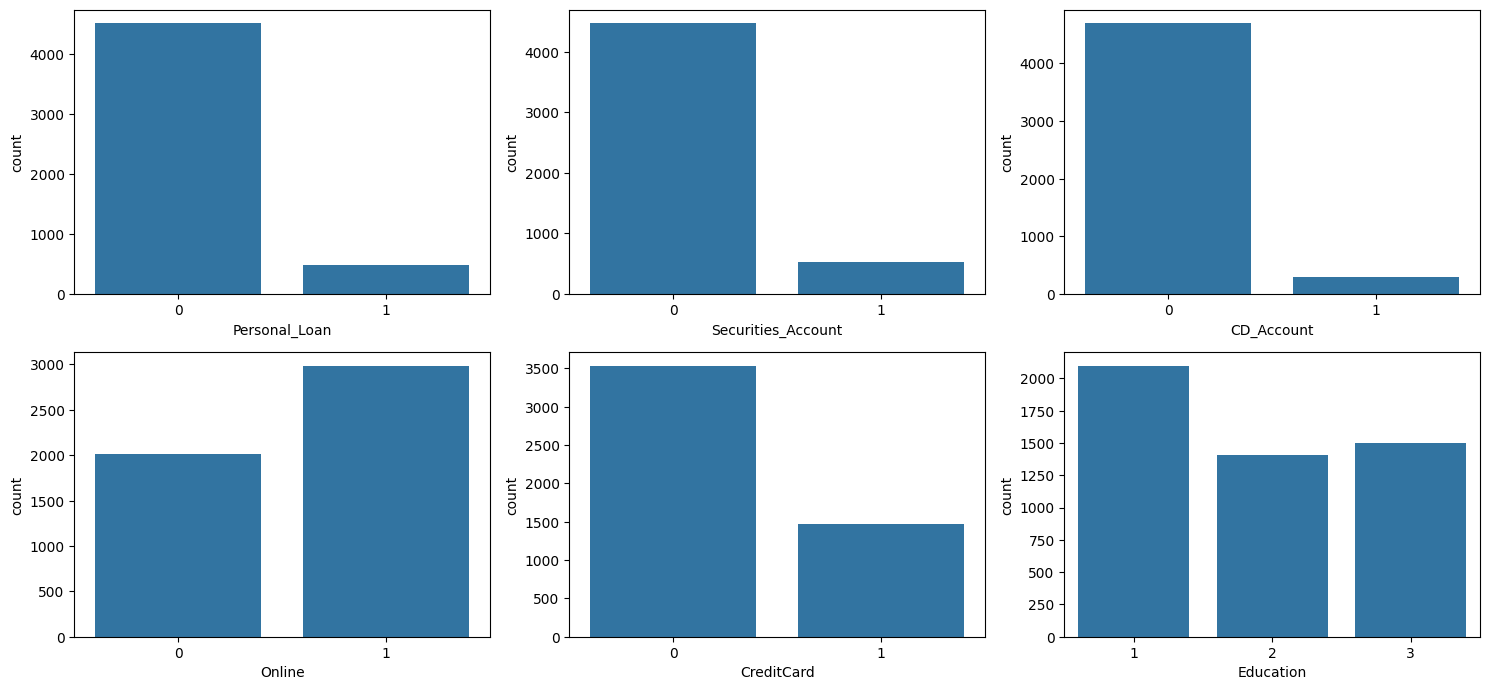

In [24]:
# checking the distribution of the categories
# defining the figure size
plt.figure(figsize=(15, 10))

cat_features = ['Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'Education']
#City is plotted separately

for i, feature in enumerate(cat_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    print(100*data[feature].value_counts(normalize=True), '\n') #Capture proportion of data distribution
    sns.countplot(data=data, x=feature)    # plot the count plot

plt.tight_layout();    # to add spacing between plots

**Observations:**

- **Personal_Loan** (Target Variable):
  - **Highly imbalanced**: 90.4% (majority) did NOT accept loan (0), only 9.6% accepted (1)

- **Securities_Account**:
  - **Highly imbalanced**: 89.56% have no account (0), only 10.44% have an account (1)
  - Most of the customers don't have securities accounts

- **CD_Account** (Certificate of Deposit):
  - **Most imbalanced feature**: 93.96% have no CD account (0), only 6.04% have a CD account (1)

- **Online** (Internet Banking):
  - **Relatively balanced**: 59.68% use online banking (1), 40.32% don't use it (0)
  - This is the most balanced categorical feature
  - Majority of the customers use online banking facilities

- **CreditCard** (Other Bank's Credit Card):
  - **Imbalanced**: 70.6% don't use other bank's credit cards (0), however 29.4% use them (1)
  - Most customers don't use credit cards from other banks

- **Education**:

  - The tallest bar is for Education Level 1 (Undergraduate). This makes up the majority of the bank's customers (typically around 42% of the data).
  - Levels 2 (Graduate) and 3 (Advanced/Professional) are roughly equal in size but smaller than Level 1.
  - While Level 1 is the biggest group, they are the least likely to accept a loan.

**Key Insights:**
- Most of the categorical features are imbalanced (except Online), which is ideally normal for customer behavior data
- The target variable (Personal_Loan) is not balanced correctly
- Undergraduates are less likely to accept a loan

Let's check the count plot for City variable

In [25]:
# Check unique City values
data['City'].nunique()

245

There are around 245 unique major cities in the dataset.

Let's plot top 10 major cities as it is difficult to plot all 245 cities.

In [26]:
top_10_cities = data['City'].value_counts().head(15)

print("Top 10 Most Frequent Cities:\n", top_10_cities)

Top 10 Most Frequent Cities:
 City
Los Angeles      375
San Diego        269
San Francisco    257
Berkeley         241
Sacramento       148
Palo Alto        130
Stanford         127
Davis            121
La Jolla         112
Santa Barbara    103
San Jose          96
Santa Clara       77
Monterey          72
Pasadena          71
Irvine            58
Name: count, dtype: int64


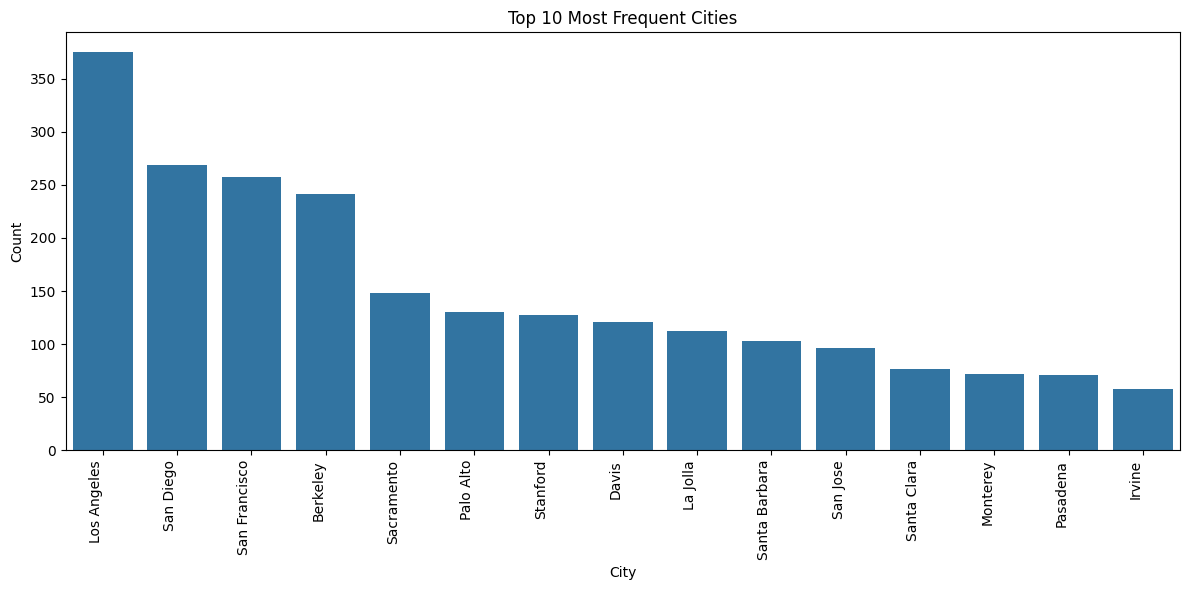

In [27]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_cities.index, y=top_10_cities.values)
plt.title('Top 10 Most Frequent Cities')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

**Observations**

1. All top 10 cities are in California, showing strong regional concentration of the bank's customer base

2. 375 customers (7.5% of dataset) are from Los Angeles. Significantly higher than second place (San Diego: 269), making it strategically important for marketing or tergeting the segments.

3. There's a sharp decline from Los Angeles to San Diego, followed by gradual decrease - indicates long-tail distribution with many cities having very few customers

5. Marketing campaigns can be prioritized among these top 5 cities (especially Los Angeles) for maximum reach and resource efficiency

#### Multi Variate Analysis

Let's try to understand the relation between numerical variables, and also between numerical and categorical variables which we have identified earlier.



##### Correlation Map

1. Plot correlation map for all the numeric variables, along with other binary categorical variables.
2. This helps in understanding the correlation with numeric variables.

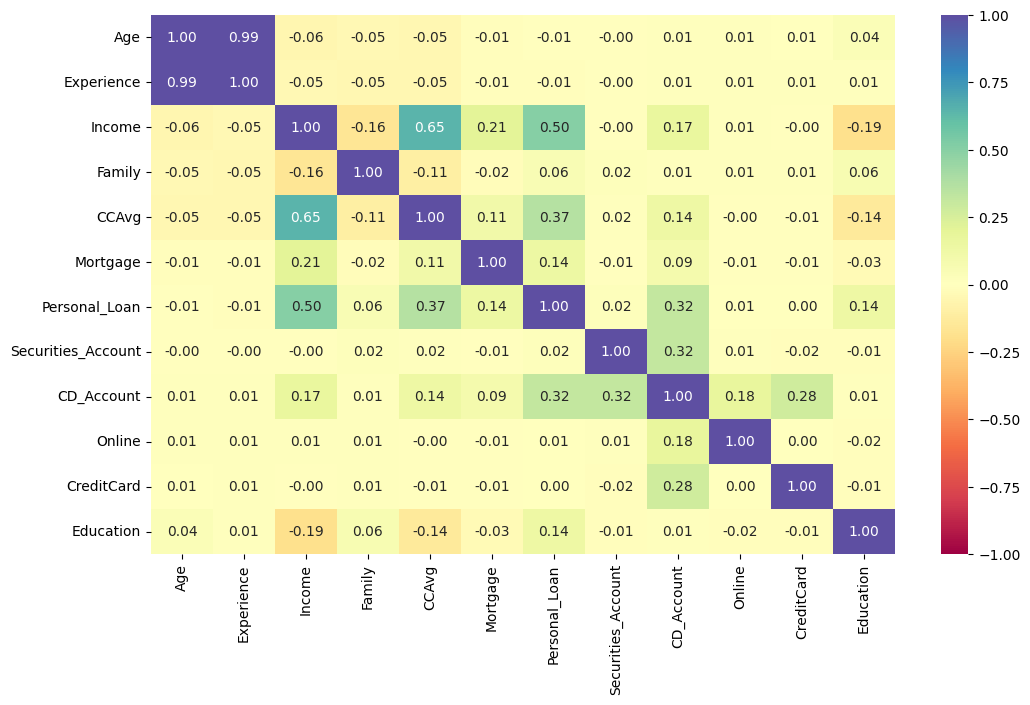

In [28]:
# defining the size of the plot
plt.figure(figsize=(12, 7))

all_features = num_features + cat_features #Combine all features to plot heatmap

# plotting the heatmap for correlation
sns.heatmap(
    data[all_features].corr(),annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
);

**Observations:**

1. There's a high multicollinearity between Age and Experience, it can be observed that there is a near-perfect positive correlation (0.99) between Age and Experience.

2. Personal Loan (Target Variable) has positive correlation with Income (0.50), CCAvg (0.37) and CD_Account (0.32).
  - Suggests that high income customers are significantly more likely to accept personal loan
  - Active CC spenders can also become a good target

3. There is a strong positive correlation (0.65) between Income and CCAvg.

4. Weak/No Correlation with Personal Loan for Age (-0.01), Experience (-0.01), Online (0.01), and CreditCard (0.00)

To improve the campaign's success rate, the model should prioritize high income customers (Income) who are active spenders (CCAvg) and perhaps already engaged in some investments/deposits (CD_Account).

##### Pair Plot

Let's try to understand the relation betweeb numerical variables against our target Personal_Loan

<Figure size 1200x800 with 0 Axes>

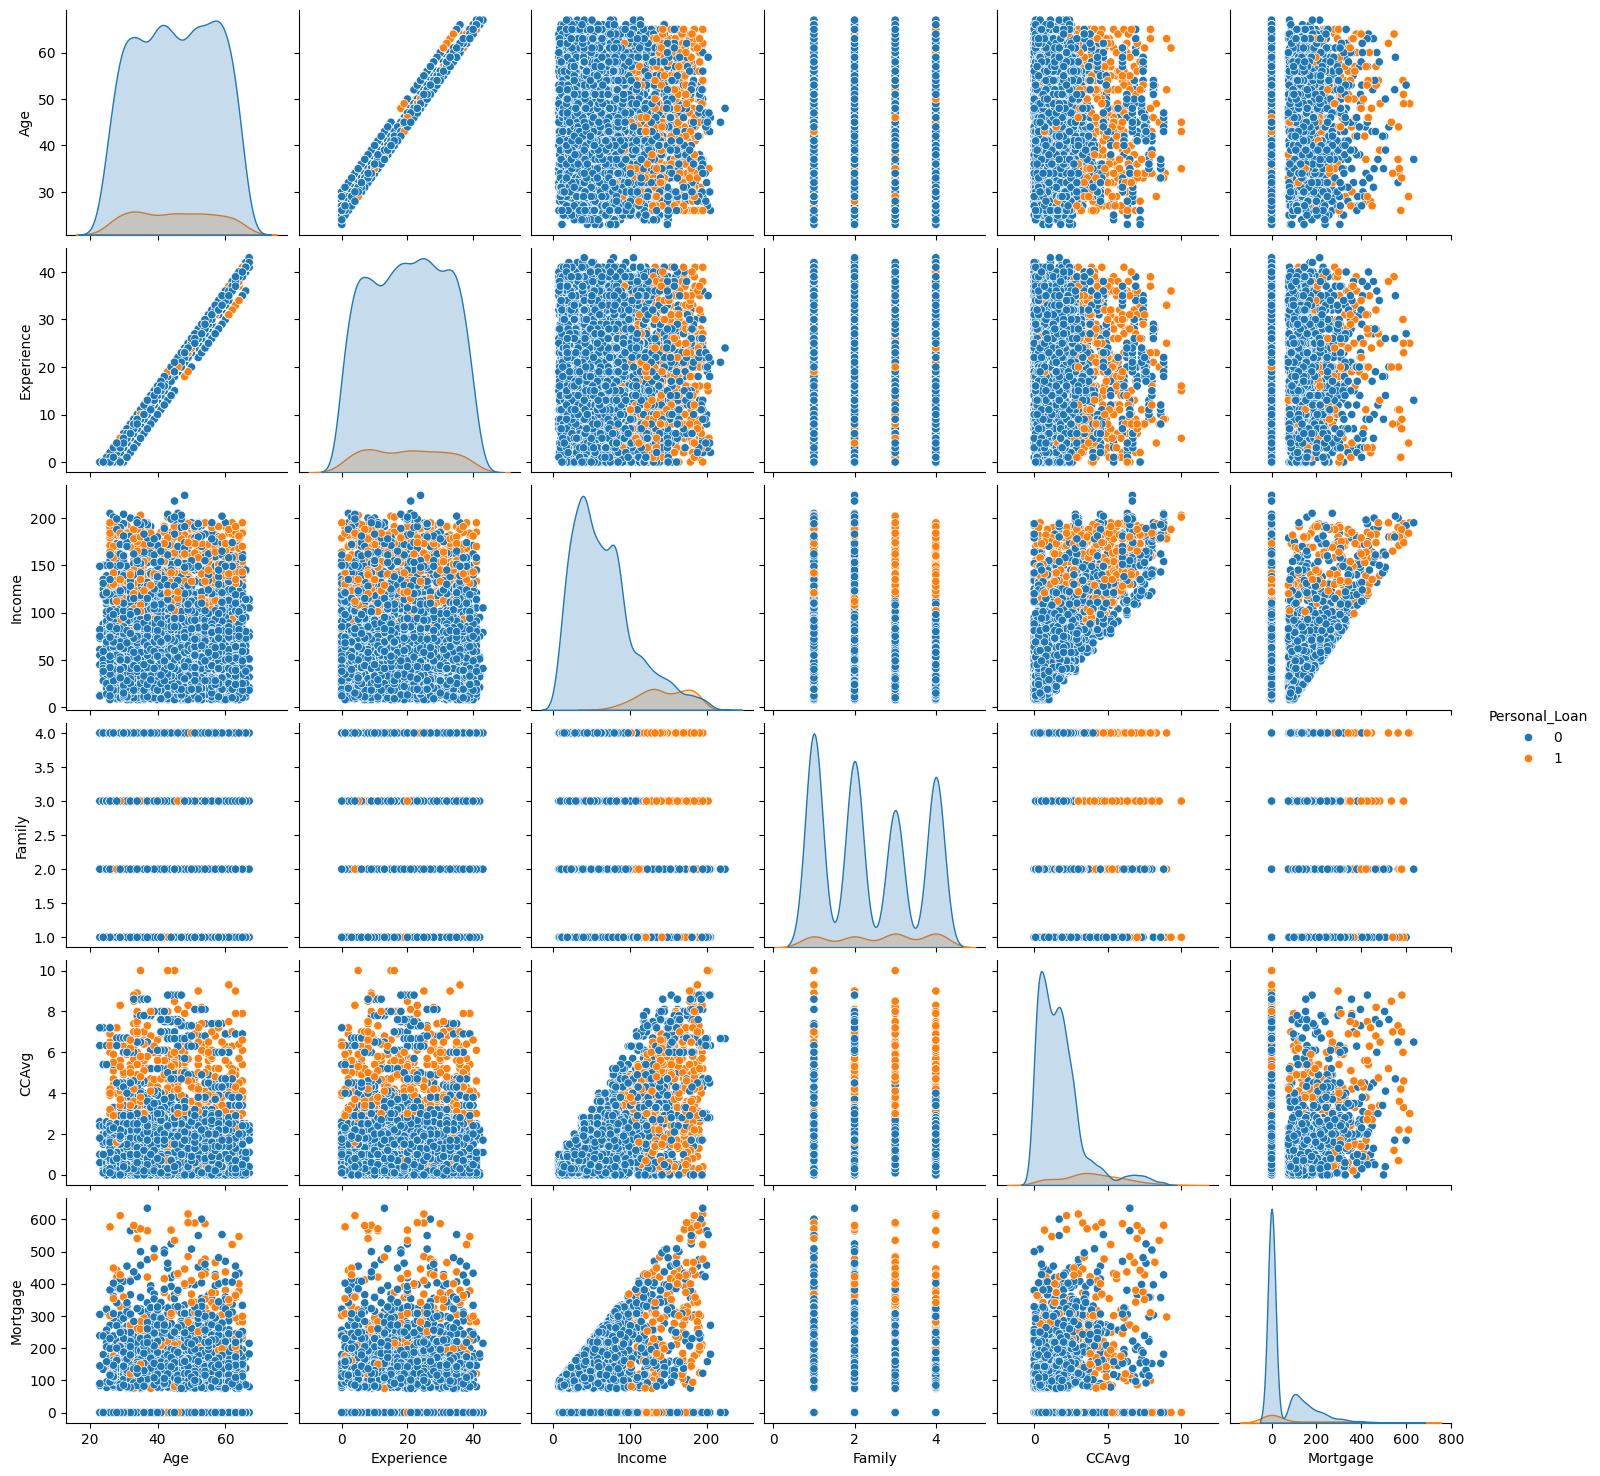

In [29]:
# Scatter Pair plot matrix
plt.figure(figsize=(12, 8))
sns.pairplot(data, vars=num_features, hue='Personal_Loan', diag_kind='kde')
plt.show()

**Observations:**

1. The scatter plot for Age vs Experience forms straight line, shows direct positive correlation. This is also confirmed in our previous analysis

2. Income vs CCAvg shows good correlation

3. The model should rely on Income and CCAvg (Spending) to predict acceptable loan rate.

##### Numerical vs Target(Personal_Loan)

**Let's try to understand relation between target variable and other numerical, binary categorical variables**

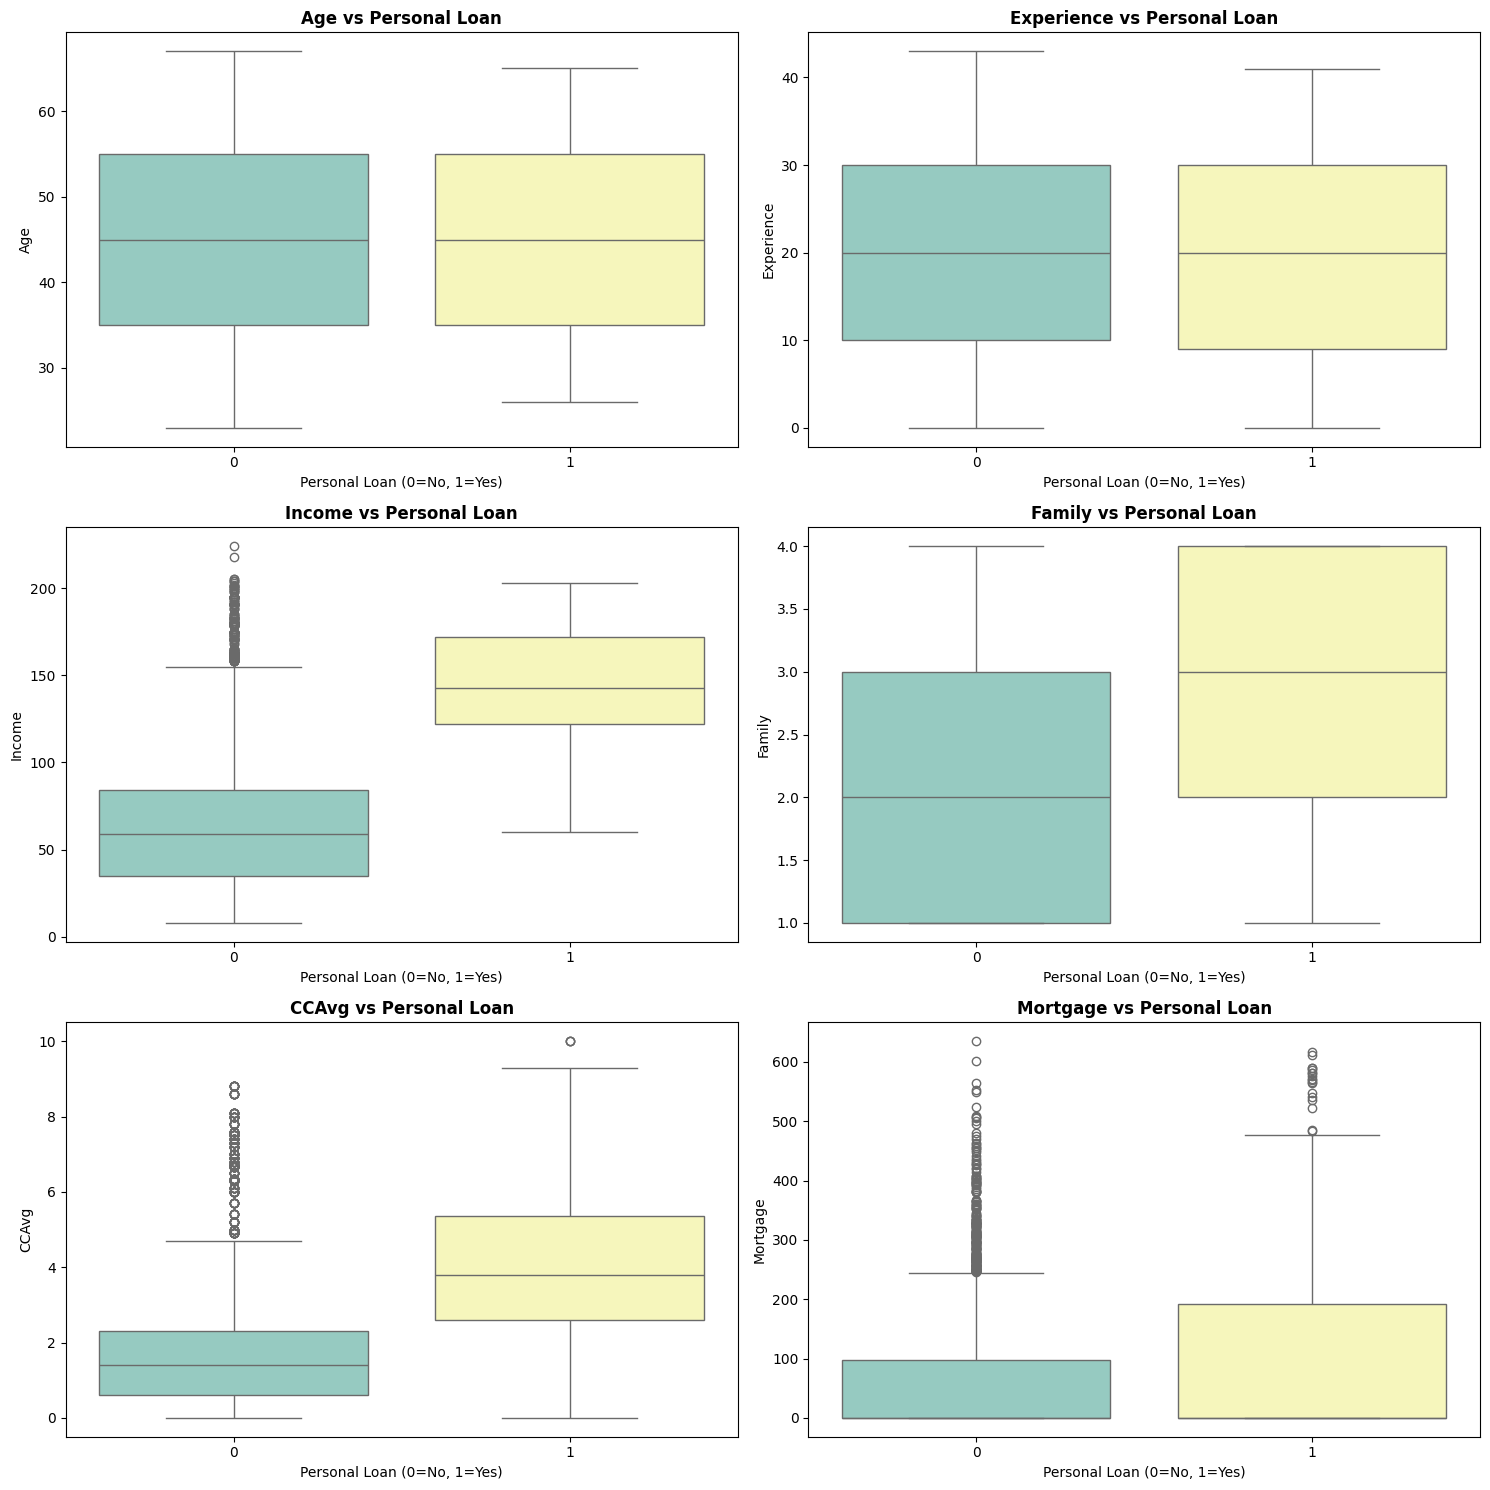

In [30]:
# Numerical features vs Target

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.ravel()

for idx, col in enumerate(num_features):
    sns.boxplot(data=data, x='Personal_Loan', y=col, ax=axes[idx], palette='Set3')
    axes[idx].set_title(f'{col} vs Personal Loan', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Personal Loan (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

**Observations:**

The boxplots validate the heatmap findings by visualizing the distribution of key features against the target variable (Personal Loan: 0 = No, 1 = Yes).

1. Customers who accepted the loan(1) have higher median income (140k) compared to those who didn't (60k)

2. Similar to Income, customers who accepted the loan have a higher average credit card spending (median ~4.0) compared to non-borrowers (median ~1.5).

3. The median family size for loan takers is higher (3) compared to non-takers (2).

4. Coming to Age & Experience, the boxplots for 0 and 1 are nearly identical. This confirms multicollinearity between these two variables; and have equal distribution of accepting/not accepting the loan

##### Categorical features vs Target(Personal_Loan)

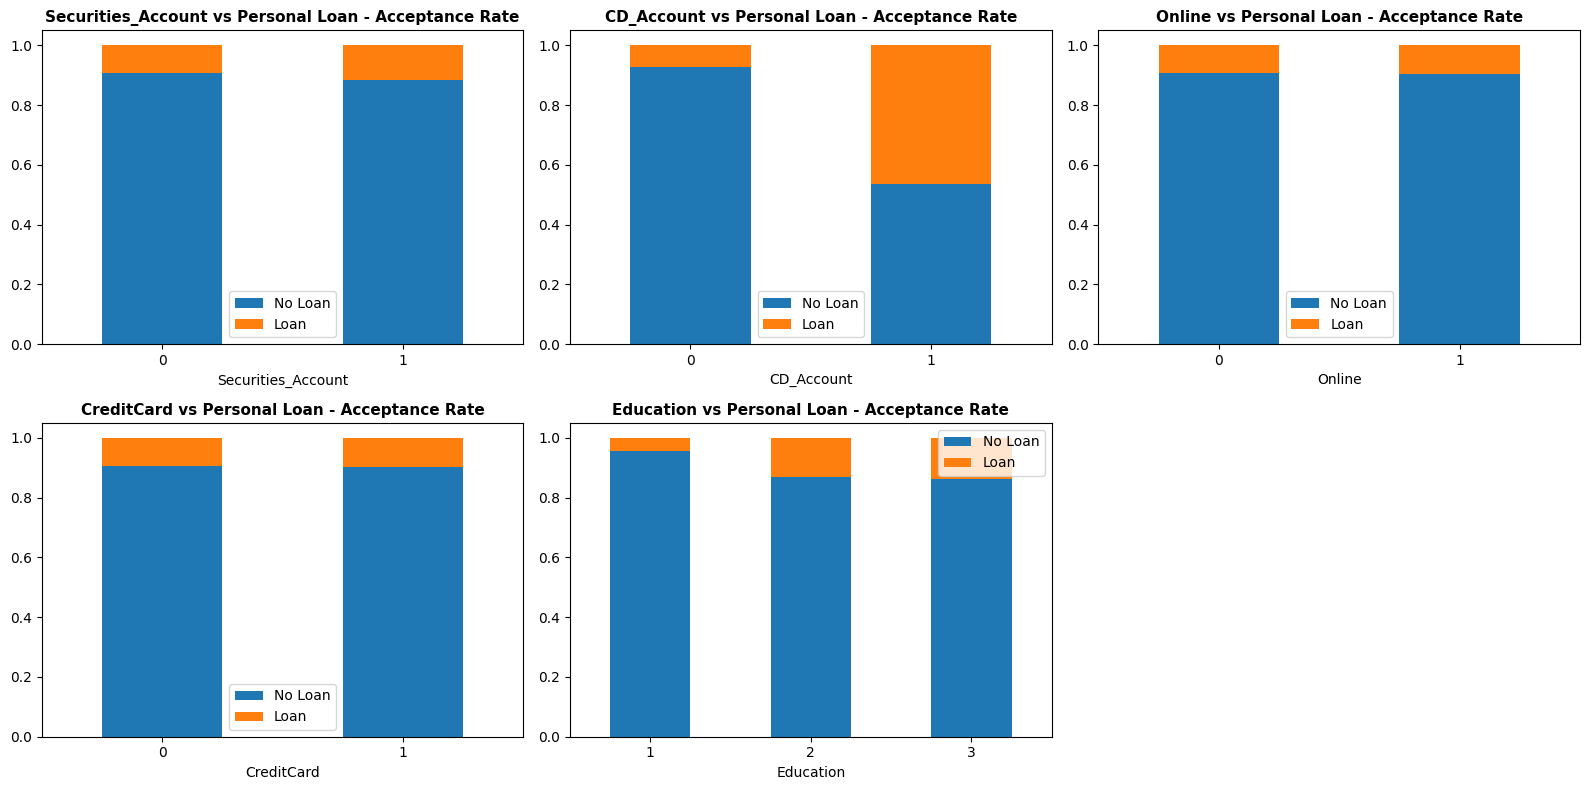

In [31]:
# Categorical features vs Target
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

# Remove 'Personal_Loan' from cat_features
plot_features = [col for col in cat_features if col != 'Personal_Loan']

for idx, col in enumerate(plot_features):

    pd.crosstab(data[col], data['Personal_Loan'], normalize='index').plot(
        kind='bar', ax=axes[idx], stacked=True)
    axes[idx].set_title(f'{col} vs Personal Loan - Acceptance Rate', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].legend(['No Loan', 'Loan'])
    axes[idx].tick_params(axis='x', rotation=0)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

**Observations:**

1. CD Account shows the most significant difference. Customers who possess a CD account have a higher loan acceptance rate compared to those who do not.

2. Securities Account, Online Banking & Credit Card Holding doesn't show much significance in availing personal loans

3. Customers with professional or graduate education are significantly more likely to opt for the loan compared to undergraduates

##### Plot to show the relation between City and Personal Loan

In [32]:
# Capture average personal loan rate per city
city_rate = data.groupby('City')['Personal_Loan'].mean().sort_values(ascending=False)

# Capture top cities with more than 20 customers
top_cities_customers = city_rate[data['City'].value_counts() >= 20].head(15)


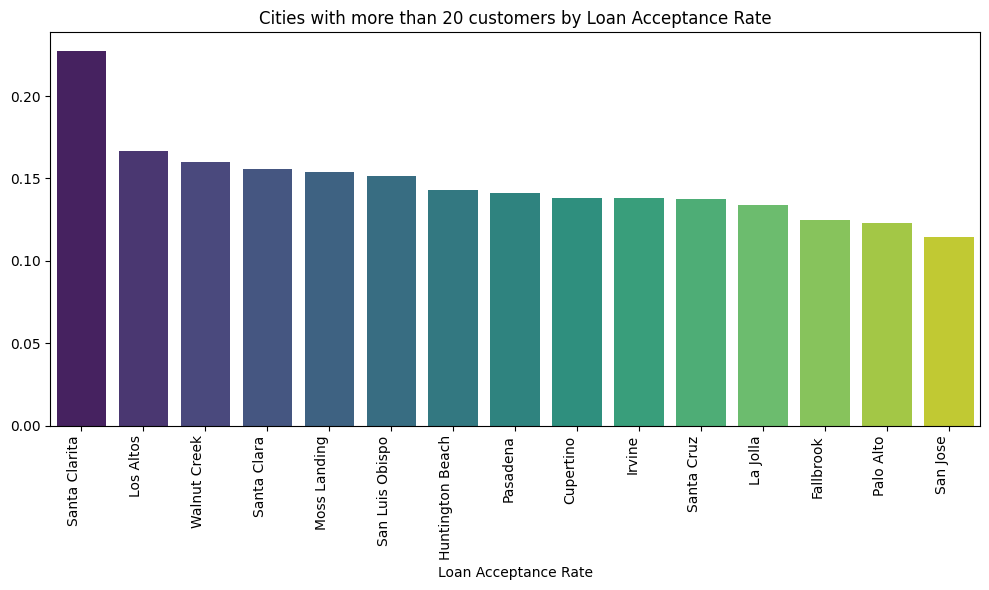

In [33]:
# Plot bar graph for top cities with more than 20 customers
plt.figure(figsize=(10, 6))
sns.barplot(x=top_cities_customers.index, y=top_cities_customers.values, palette='viridis')
plt.xlabel('Loan Acceptance Rate')
plt.title('Cities with more than 20 customers by Loan Acceptance Rate')
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

**Observations:**

1. If we consider the cities with more than 20 customers personal loan acceptance rate, Santa Clarita has the highest loan acceptance rate compared with others, exceeding 20% (0.23).
4. Los Altos, Walnut Creek, and Santa Clara shows strong acceptance rates ranging between 15% and 17%.
5. All other cities shows less acceptance rate nearing to 0-1.
6. This signifies City is not much correlated to the target (Personal Loan) feature

**Preliminary modeling experiment for City**


Based on exploratory data analysis and a preliminary decision tree experiment, the City feature was found to have no predictive contribution, as it was not selected for any splits in the tree and resulted in zero feature importance compared to other variables.

> ** *Supported charts are attached in the Appendix section of this notebook*



### Data Preparation for Modeling

- Based on our analysis, **Personal_Loan** is the target variable.
- Age and Experience confirms multilinear correlation, but this might not have significant impact for decision tree model.
- Education is an ordinal variable, where it holds numerical values in order, the decision tree treats these values properly, so one-hot encoding is not needed
- **ZIPCode** feature which is converted to **City** has around 245 unique values. As this is categorical variable, performing one-hot encoding on this feature will result in 244 additional columns, which adds high cardinality to the dataset (just with 0's and 1's).
- **Feature Engineering:** Based on our previous analysis, City can be safely dropped as this feature has very limited incremental predictive power.
  - *Preliminary modeling experiment suggested that including City did not impact much on performance of the model.*
- The variation observed across cities is largely explained by variables such as income and credit card usage. Including City may increase the model complexity and risk of overfitting without significantly improving performance.

*** ***Premiliminary analysis feature importance chart with top 5 cities is included in Appendix***

In [34]:
# Assign target variable to 'y'
y = data["Personal_Loan"]

# Drop the relevant features that are not needed for model predictions
# Personal_Loan is a target variable, hence dropped from input features
# City feature has high cardinality, and doesn't improve model's performance. Hence dropped from input features
X = data.drop(["Personal_Loan", "City"], axis=1)

# Ensure all columns are float type
X = X.astype(float)

# splitting the data in an 70:30 ratio for train and test sets
# stratify 'yes' parameter makes sure the data split is balanced across the classes for training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)


In [35]:
print("Shape of training set:", X_train.shape)
print("Shape of test set:", X_test.shape, '\n')

print("Percentage of classes in training set:")
print(100*y_train.value_counts(normalize=True), '\n')
print("Percentage of classes in test set:")
print(100*y_test.value_counts(normalize=True))

Shape of training set: (3500, 11)
Shape of test set: (1500, 11) 

Percentage of classes in training set:
Personal_Loan
0   90.40000
1    9.60000
Name: proportion, dtype: float64 

Percentage of classes in test set:
Personal_Loan
0   90.40000
1    9.60000
Name: proportion, dtype: float64


NOTE:

1. It can be observed that the proportion is divided perfectly for training set and test set.

2. 90.4% did not take the loan, while remaining 9.6% did accept the loan.

3. To highlight, the target variable Personal_Loan is highly skewed, so the key pointer here would be to not to completely rely on accuracy, but focus on Recall and Precision (f1 score)

4. Balancing the class proportion while predicting the model also plays a crucial role

### Model Building

### Decision Tree (default)

Instantiate and fit decision tree model on training data

In [36]:
# Create an instance of the decision tree model
plain_dtree = DecisionTreeClassifier(random_state=42)    # random_state sets a seed value and enables reproducibility

# Fit the model to the training data
plain_dtree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

#### Model Evaluation

1. Model can make wrong prediction predicting a customer will accept the loan but in reality, customer doesn't accept the loan, which comes under False Positive error

2. Model can make wrong prediction predicting a customer will not accept the loan but in reality, customer would accept the loan, which comes under False Negative error

3. False negatives are more important for this use case, since missing customer loan results in high revenue loss vs wasting amount for campaigns.

4. To reduce the bank's revenue loss, greater/highest the recall score, will improve the chances of minimising false negatives.

Define functions to compute different metrics and confusion matrix

In [37]:
# Define a function to compute accuracy score, recall score, precision score and f1 score of classification model

def model_performance(model, predictors, target):
    """
    Function to compute accuracy score, recall score, precision score and f1 score to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable

    """

    # Predict with the independent variables (predictors)
    pred = model.predict(predictors)

    accuracy = accuracy_score(target, pred)  # Compute Accuracy
    recall = recall_score(target, pred)  # Compute Recall
    precision = precision_score(target, pred)  # Compute Precision
    f1 = f1_score(target, pred)  # Compute F1-score

    # Create a dataframe of all the metrics
    df_performance = pd.DataFrame(
        {"Accuracy": accuracy, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_performance

In [38]:
# Define a function that generates a heat map of TP, TN, FP, and FN values

def plot_confusion_matrix(model, predictors, target):

    """
    Plot the confusion_matrix

    model: classifier
    predictors: independent variables
    target: dependent variable

    """
    # Predict the target values using the provided model and predictors
    y_pred = model.predict(predictors)

    # Compute the confusion matrix by comparing the true target values with the predicted values
    cm = confusion_matrix(target, y_pred)

    # Create labels for each cell in the confusion matrix with both count and percentage
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2) # 2*2 matrix containing TN, FN, FP, TP

    plt.figure(figsize=(6, 4))

    # Plot the confusion matrix as a heatmap
    sns.heatmap(cm, annot=labels, fmt="")

    plt.ylabel("True")
    plt.xlabel("Predicted")

Let's plot confusion matrix to see the performance of training data

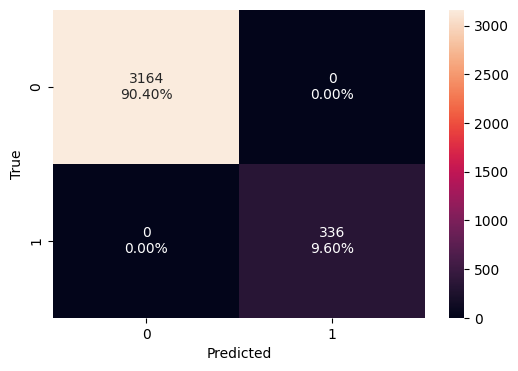

In [39]:
plot_confusion_matrix(plain_dtree, X_train, y_train)

**Observations:**

- The confusion matrix shows 100% perfect classification with zero false positives and false negatives.
- While this indicates strong model performance on the training dataset, this suggest a overfitting model

In [40]:
plain_dtree_train_perf = model_performance(
    plain_dtree, X_train, y_train
)
plain_dtree_train_perf

,Accuracy,Recall,Precision,F1
0,1.00000,1.00000,1.00000,1.00000


**Observations:**

- The evaluation parameters also suggests this is perfect model.
- However, this is not realistic and it is clearly evident the model has overfit the data.

Let's plot confusion matrix for test data with the same model

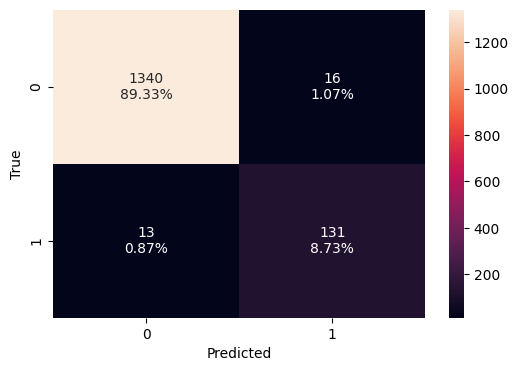

In [41]:
# Plot confusion matrix for test data
plot_confusion_matrix(plain_dtree, X_test, y_test)

**Observations:**

1. The confusion matrix on test data shows variation. There's around 16 (1.07%) false positives, and around 13 false negatives (0.87%)
2. Though train data is perfect, test data showed some errors against the same model

In [42]:
# Invoke model performance method that calculates performance evaluation metrics

plain_dtree_test_perf = model_performance(
    plain_dtree, X_test, y_test
)
plain_dtree_test_perf

,Accuracy,Recall,Precision,F1
0,0.98067,0.90972,0.89116,0.90034


**Observations:**

1. The evaluation parameters for test data shows around ~10% difference with training data
2. This large gap indicates overfitting problem and is not a good model to progress

#### Visualize the Decision Tree

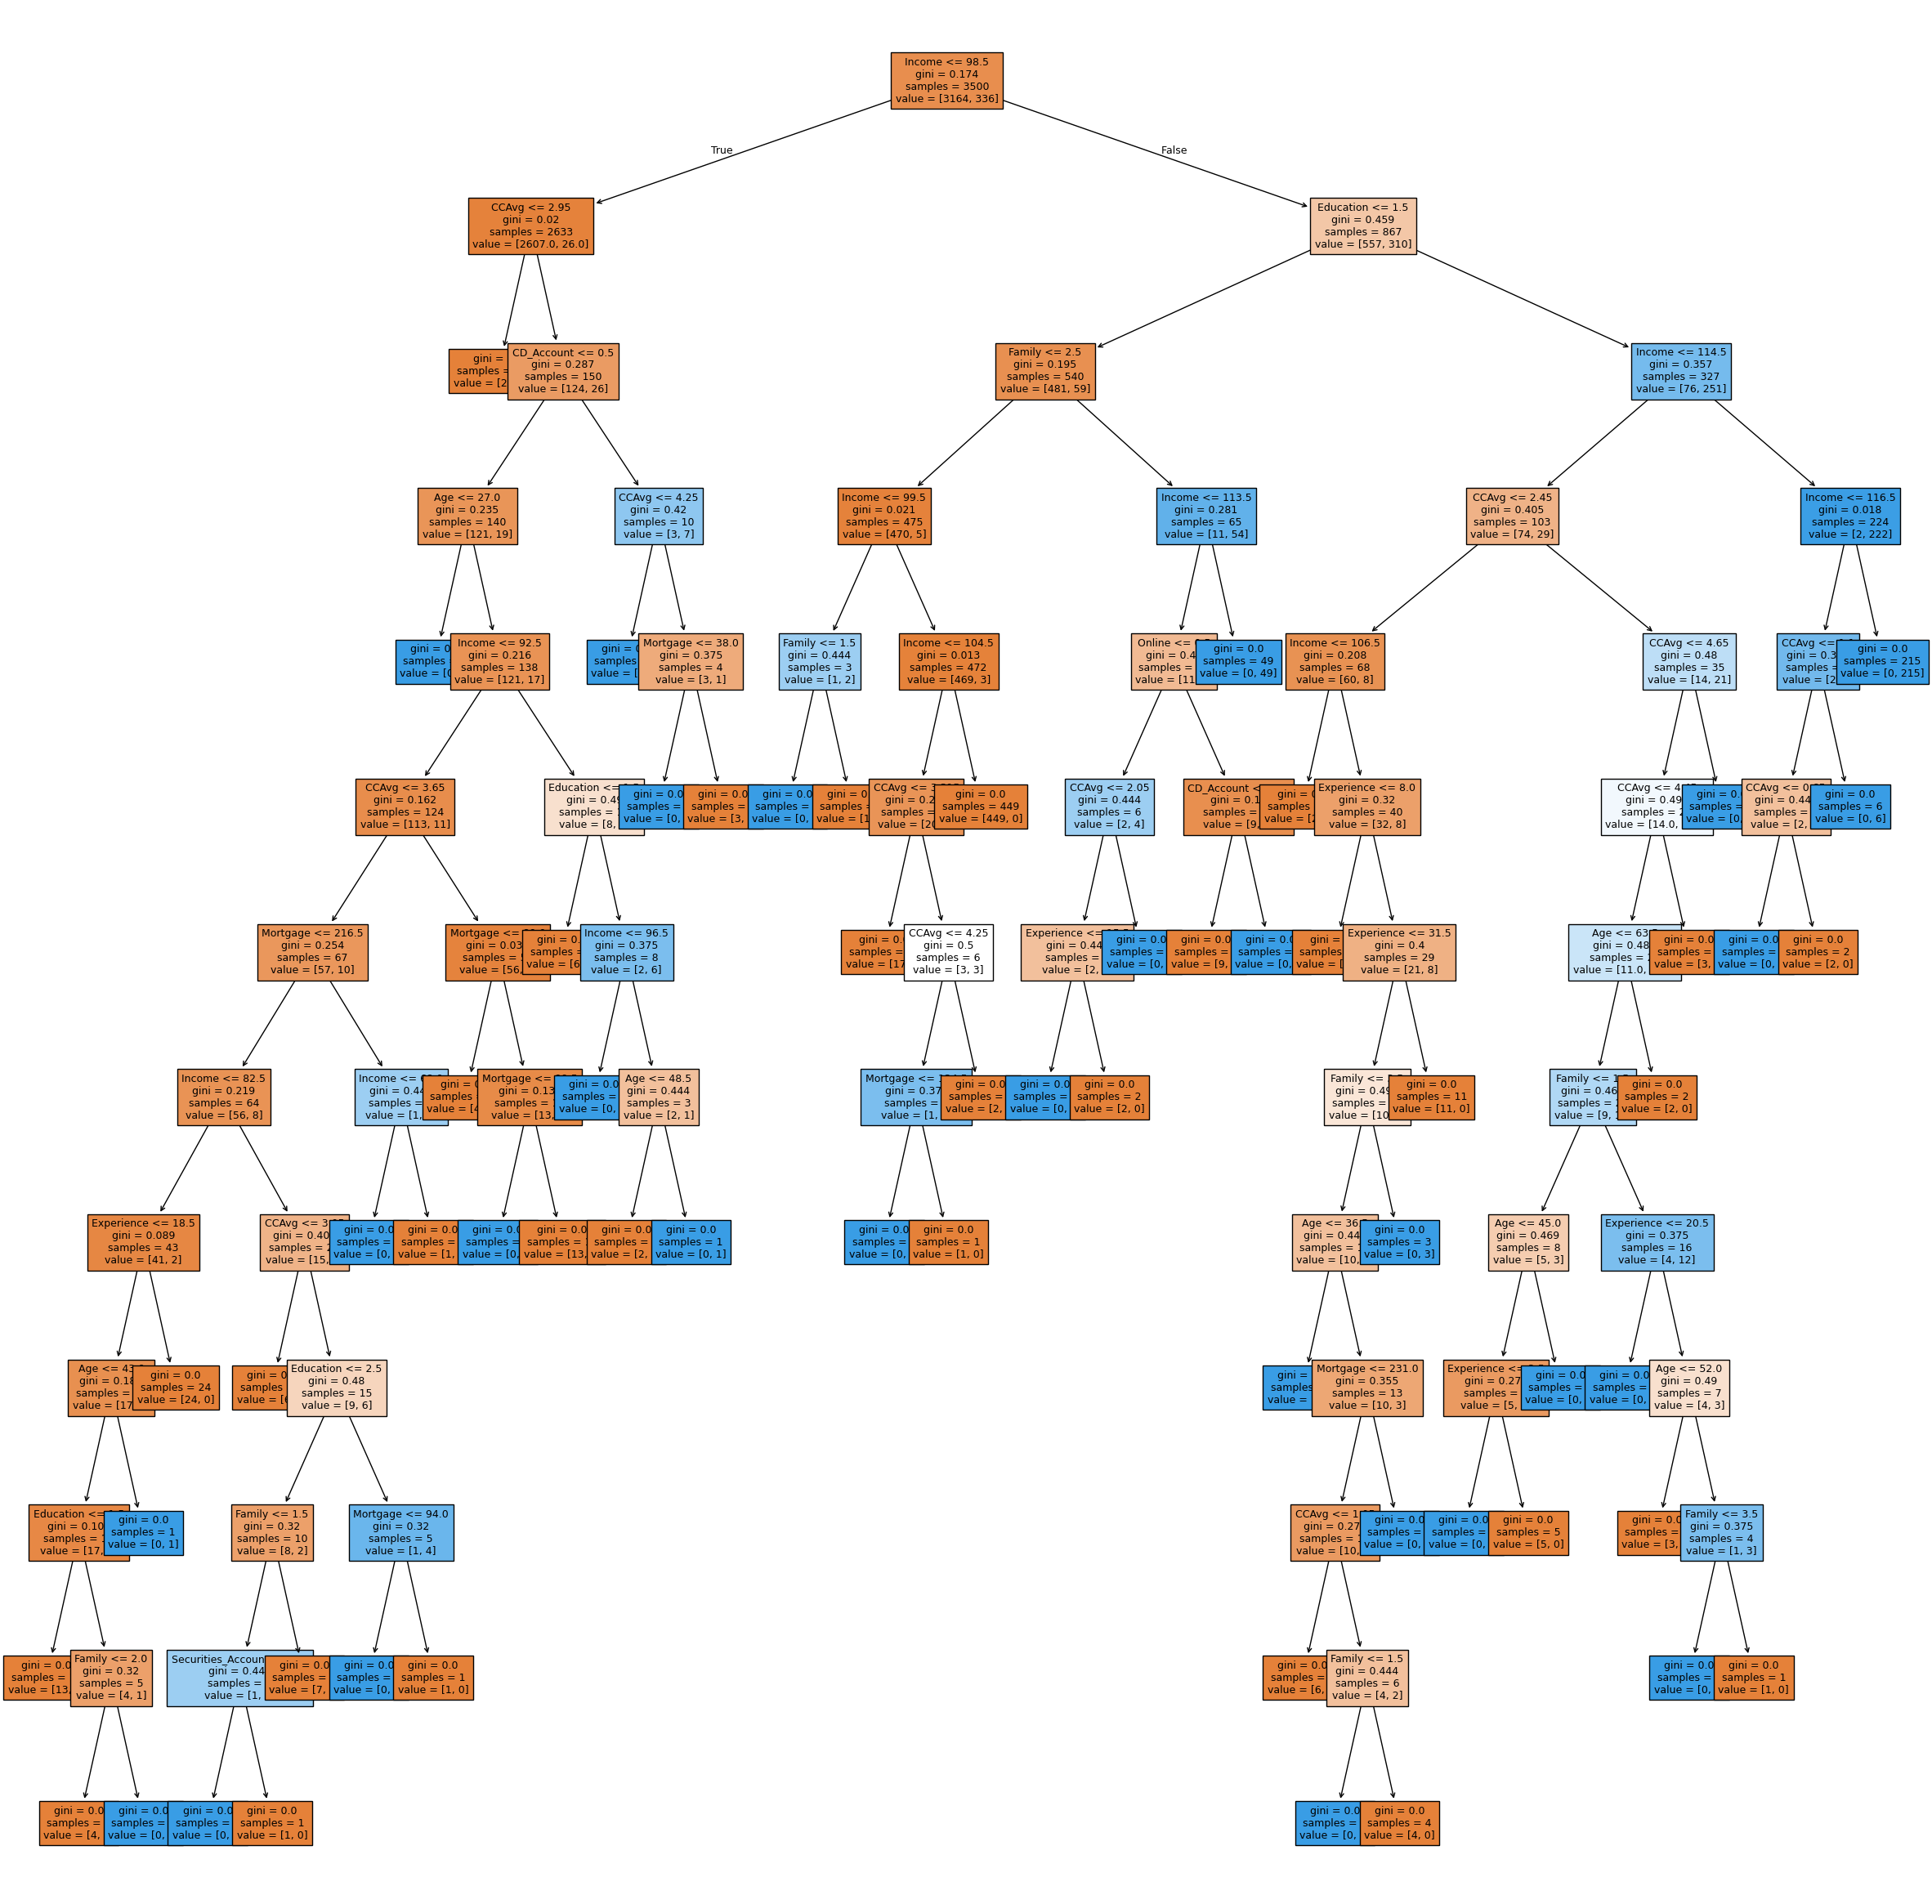

In [43]:
# capture list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(30, 30))

# Plot the decision tree
outputTree = tree.plot_tree(
    plain_dtree,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # Not to display class names
)

# add arrows to the decision tree splits if they are missing
for output in outputTree:
    arrow = output.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

plt.show()

- From the above tree graph, we can observe that this is a very complex tree

Let's print the text form of the decision tree for this model

In [44]:
# Print a text form of decision tree
print(tree.export_text(
        plain_dtree,    # decision tree model
        feature_names=feature_names,    # Feature names
        show_weights=True    # Show the weights associated with the model
    ))

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2483.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Age <= 27.00
|   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |--- Age >  27.00
|   |   |   |   |--- Income <= 92.50
|   |   |   |   |   |--- CCAvg <= 3.65
|   |   |   |   |   |   |--- Mortgage <= 216.50
|   |   |   |   |   |   |   |--- Income <= 82.50
|   |   |   |   |   |   |   |   |--- Experience <= 18.50
|   |   |   |   |   |   |   |   |   |--- Age <= 43.00
|   |   |   |   |   |   |   |   |   |   |--- Education <= 1.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [13.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |   |   |--- Education >  1.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |--- Age >  43.00
|   |   |   |   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |   |   |   |--- Experie

It is clear that the tree is complex and overfitting. Let's try to pre-prune the tree

### Decision Tree (Pre-Pruning)

* Pre-pruning refers to the process of defining hyper parameters i.e., define the optimal depth, leaf nodes, samples upfront that avoids overfitting the tree

* Grid Search is a tuning technique that tries to compute optimal hyper parameter values. It performs exhaustive search on these specific parameter values of a model

* As part of pre-pruning process, let's define hyper parameters and build the model based on these parameters

* Let's use GridSearch technique for hyper parameter tuning of our tree model


In [45]:
# Initialize decision tree classifier

estimator = DecisionTreeClassifier(random_state=42)

# Grid of parameters to choose
parameters = {
    "class_weight": [None, "balanced"], #Evaluate both unweighted and class-balanced trees to handle class imbalance
    "max_depth": np.arange(2, 11, 2), # Maximum depths of 2, 4, 6, 8, 10 levels
    "max_leaf_nodes": np.arange(10, 51, 10), # At most 10, 20, 30, 40, 50 leaf nodes
    "min_samples_split": np.arange(10, 51, 10), # Split a node with at least 10, 20, 30, 40, 50 samples
}

# Let's take F1 score as our metric
f1_scorer = make_scorer(f1_score)

# Run the grid search
grid_obj = GridSearchCV(estimator, parameters, scoring=f1_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
estimator.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=np.int64(6), max_leaf_nodes=np.int64(10),
                       min_samples_split=np.int64(20), random_state=42)

In [46]:
# Create an instance of the best model defined as estimator in previous step
preprune_dtree = estimator

# Now fit the best model to the training data
preprune_dtree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=np.int64(6), max_leaf_nodes=np.int64(10),
                       min_samples_split=np.int64(20), random_state=42)

Model is now fit with the training data. Now let's plot confusion matrix and see the results

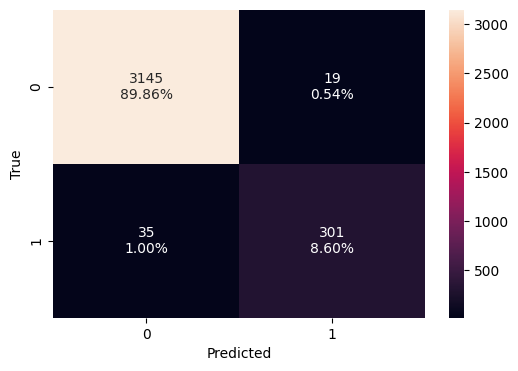

In [47]:
# Plot confusion matrix with pre-pruned decision tree model

plot_confusion_matrix(preprune_dtree, X_train, y_train)

**Observations:**

- The confusion matrix shows 89% true negative, 0.54% false positive, 1% false negative and 8.60% true positive.
- This is different to what we have seen in earlier overfitting model

In [48]:
 # Invoke model performance method that calculates performance evaluation metrics for training data

preprune_dtree_train_perf = model_performance(
    preprune_dtree, X_train, y_train
)
preprune_dtree_train_perf

,Accuracy,Recall,Precision,F1
0,0.98457,0.89583,0.94063,0.91768


- This model suggests around 98% accuracy for training set, followed with 89% recall, 94% precision and 91% F1 score.
- We need highest recall to ensure no false negatives as per the evaluation metrics.

Let's plot confusion matrix for test data

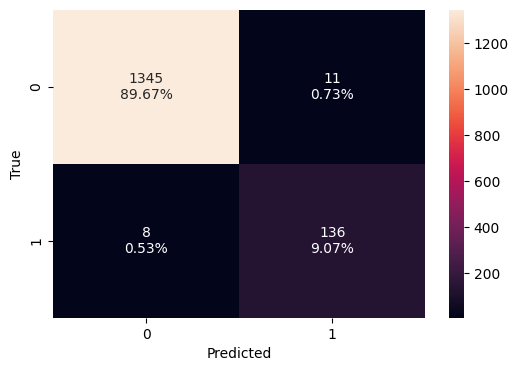

In [49]:
plot_confusion_matrix(preprune_dtree, X_test, y_test)

**Observations:**

- The confusion matrix shows 89% true negative, 0.73% false positive, 0.53% false negative and 9.07% true positive.
- This shows some difference to the training scores

In [50]:
# Invoke model performance method that calculates performance evaluation metrics for test data

preprune_dtree_test_perf = model_performance(
    preprune_dtree, X_test, y_test
)
preprune_dtree_test_perf

,Accuracy,Recall,Precision,F1
0,0.98733,0.94444,0.92517,0.93471


- This model suggests around 98% accuracy for testing set, followed with 94% recall, 92% precision and 93% F1 score.
- Recall and F1 score is better with test data which is a good sign. Precision has slight downgrade to 92%

#### Visualize the Decision Tree

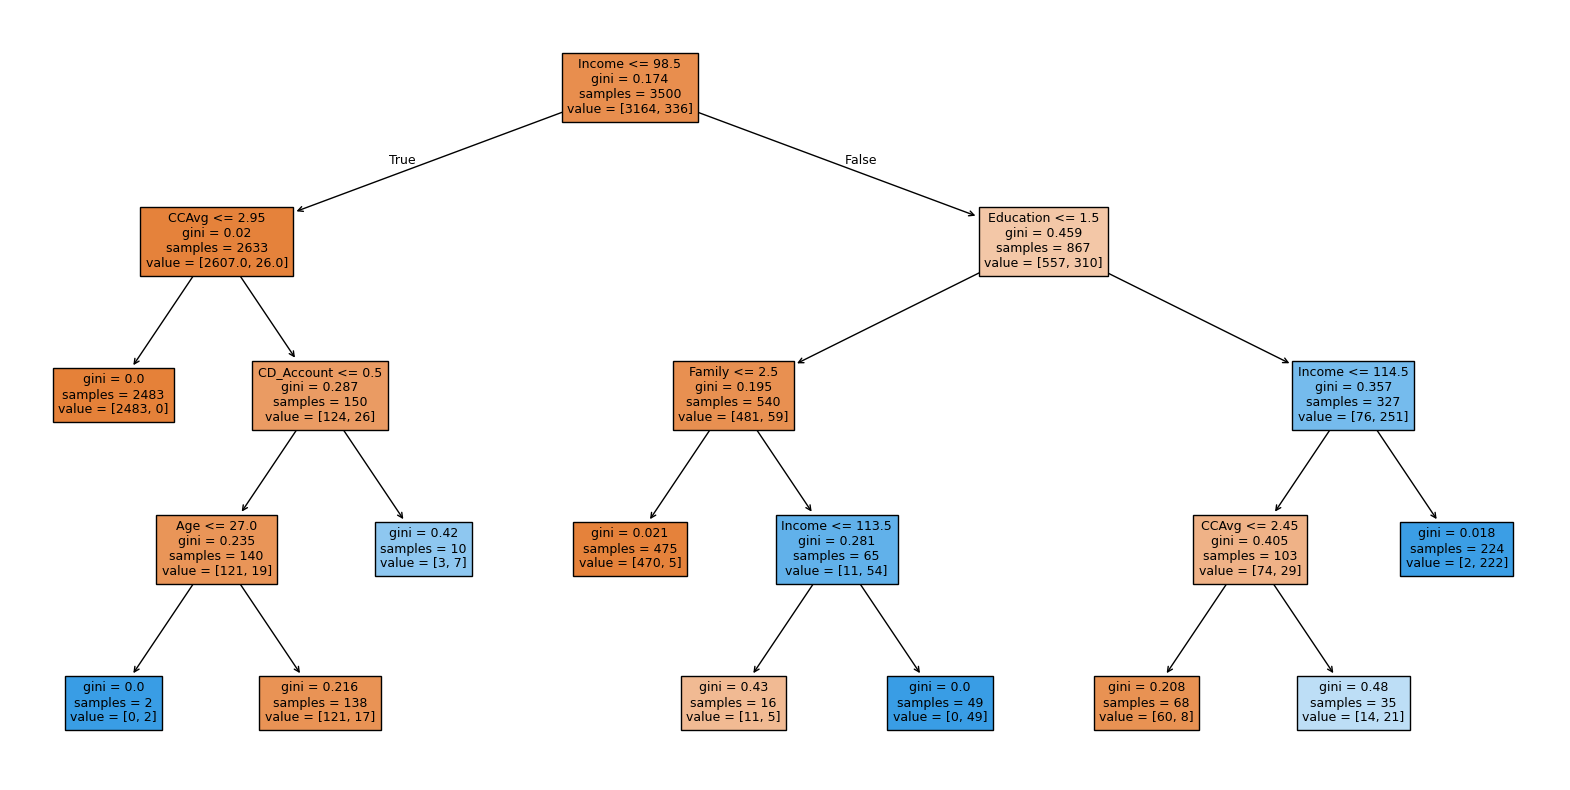

In [51]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 10))

# plotting the decision tree
outTree = tree.plot_tree(
    preprune_dtree,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for out in outTree:
    arrow = out.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

- The decision tree is less complex than the previous tree
- Samples count, Gini index, and decision rules are clearly visible in this tree plot, and it fits well.

Let's print the text form of the decision tree for this model

In [52]:
# Print a text form of decision tree
print(
    tree.export_text(
        preprune_dtree,    # Model - preprune_dtree
        feature_names=feature_names,    # Feature names
        show_weights=True    # Show the weights associated with the model
    )
)

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2483.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Age <= 27.00
|   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |--- Age >  27.00
|   |   |   |   |--- weights: [121.00, 17.00] class: 0
|   |   |--- CD_Account >  0.50
|   |   |   |--- weights: [3.00, 7.00] class: 1
|--- Income >  98.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- weights: [470.00, 5.00] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- Income <= 113.50
|   |   |   |   |--- weights: [11.00, 5.00] class: 0
|   |   |   |--- Income >  113.50
|   |   |   |   |--- weights: [0.00, 49.00] class: 1
|   |--- Education >  1.50
|   |   |--- Income <= 114.50
|   |   |   |--- CCAvg <= 2.45
|   |   |   |   |--- weights: [60.00, 8.00] class: 0
|   |   |   |--- CCAvg >  2.45
|   |   |   |   |--- weights: [14.00, 21.00] class: 1
|   |   |--- Income >  114.50
|   |   |   |--- weight

**Observations:**

If the income > 98.5, and if the education is higher > 1.5, with income > 114.50, then most likely the customer is expected to take personal loan.

#### Feature Importance

Overview of the importance of features used in building a model

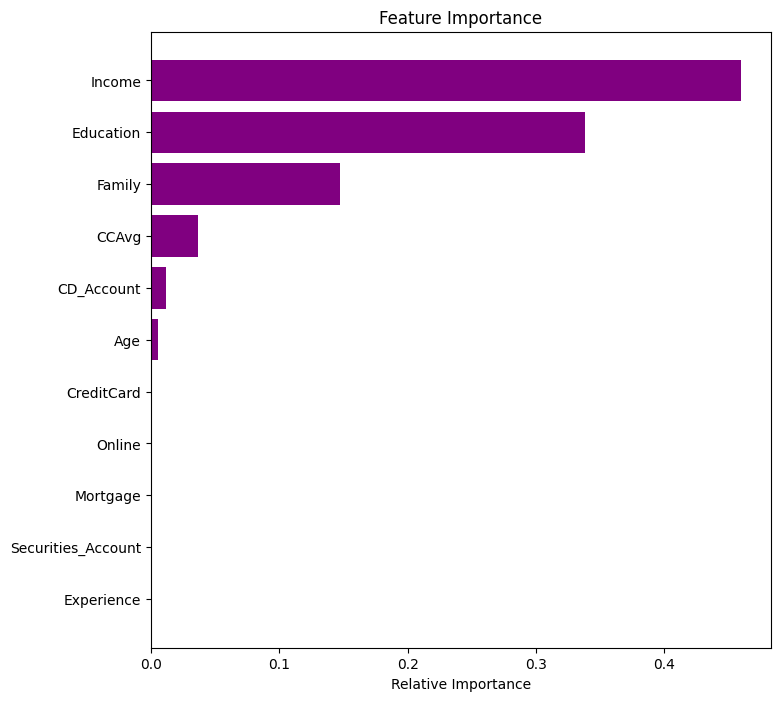

In [53]:
# importance of features in the tree building

importances = preprune_dtree.feature_importances_
indices = np.argsort(importances)

# Plot the features by importance
plt.figure(figsize=(8, 8))
plt.title("Feature Importance")
plt.barh(range(len(indices)), importances[indices], color="purple", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- Income and Education are the most influential attributes in determining personal loan acceptance
- Family and CCAvg are the next best attributes to consider

### Decision Tree (Post-Pruning)

- Cost complexity pruning is a post-pruning technique used to control the size and complexity of a decision tree after it has been fully grown. It is parameterized by a parameter called ccp_alpha (cost complexity pruning).

- Higher values of ccp_alpha increase the number of nodes pruned. Here, we show the effect of ccp_alpha on regularizing the trees and how to choose a ccp_alpha based on validation scores.

- This pruning method works by computing an effective alpha for every internal node. The node with the smallest effective alpha contributes the least to reducing impurity and is the first candidate to be pruned. The process repeats recursively thereby simplifying the tree balancing accuracy and generalization.

As part of post-pruning process, let's find out alphas and see a good fit model

In [54]:
# Create an instance of the decision tree model
dt_clf = DecisionTreeClassifier(random_state=42)

# Compute the cost complexity pruning path for the model using the training data
path = dt_clf.cost_complexity_pruning_path(X_train, y_train) # Pruning Path has alphas and impurities

# Extract alpha values
ccp_alphas = abs(path.ccp_alphas)

# Extract impurities at each alpha
impurities = path.impurities

Let's see the alpha values and impurity scores

In [55]:
pd.DataFrame(path) #View alpha score and impurity score in a dataframe

,ccp_alphas,impurities
0,0.00000,0.00000
1,0.00027,0.00054
2,0.00028,0.00109
3,0.00028,0.00165
4,0.00038,0.00278
5,0.00038,0.00316
6,0.00038,0.00355
7,0.00038,0.00393
8,0.00038,0.00431
9,0.00038,0.00507


##### Plot effective alpha and impurity for training set

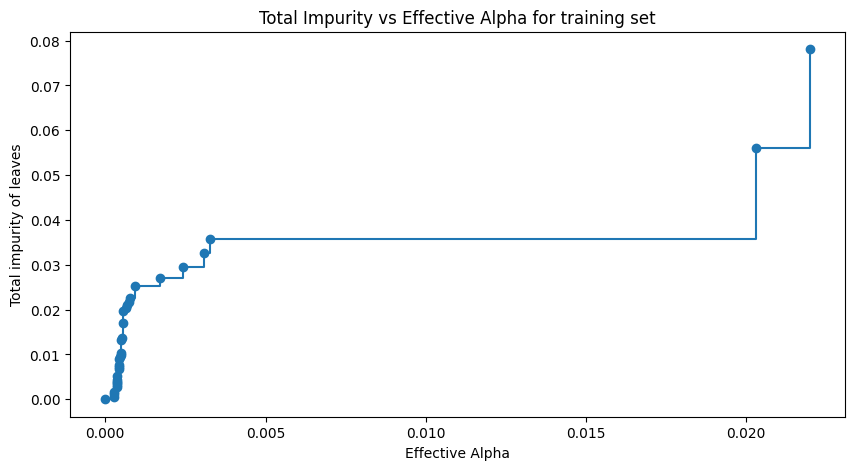

In [56]:
# Create a figure
fig, axes = plt.subplots(figsize=(10, 5))

# Plot total impurities vs alpha scores for training set
# marker is used at every data point
axes.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")

# Set the x-axis label
axes.set_xlabel("Effective Alpha")

# Set the y-axis label
axes.set_ylabel("Total impurity of leaves")

# Set the title of the plot
axes.set_title("Total Impurity vs Effective Alpha for training set");

**Observations:**


1. As the effective alpha value increases, the total impurity of leaves also increases.

2. The relationship is not a smooth curve but a series of steps. Each step corresponds to a specific alpha threshold where a branch is pruned off. Flat line represents range of aplha where the tree structure remains unchanged

Let's try to train a decision tree using the effective alphas.


In [57]:
# Initialise empty list to capture decision tree classifiers
dt_clfs = []

# Iterate over each ccp_alpha value extracted from cost complexity pruning path

for ccp_alpha in ccp_alphas:
    # Create an instance of the DecisionTreeClassifier
    dt_clf = DecisionTreeClassifier(ccp_alpha=ccp_alpha, random_state=42)

    # Fit the classifier to the training data
    dt_clf.fit(X_train, y_train)

    # Append the trained classifier to the list initialised earlier
    dt_clfs.append(dt_clf)

# Display number of nodes in final tree along with ccp_alpha value
print(
    "Number of nodes in the last tree is {} with ccp_alpha {}".format(
        dt_clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is 1 with ccp_alpha 0.04774589891961516


**Observations:**

- Last tree has only one node with alpha as 0.047
- Let's proceed with removing last element in the tree, as it corresponds to simple/trivial tree with only one node

**Important note:**

- Explicit class weighting was excluded to avoid instability of splits to the minority class (which increases model variance) and inflating the false positive.
- Instead, post-pruning was prioritized to balance model complexity and ensure a generalized decision boundary.

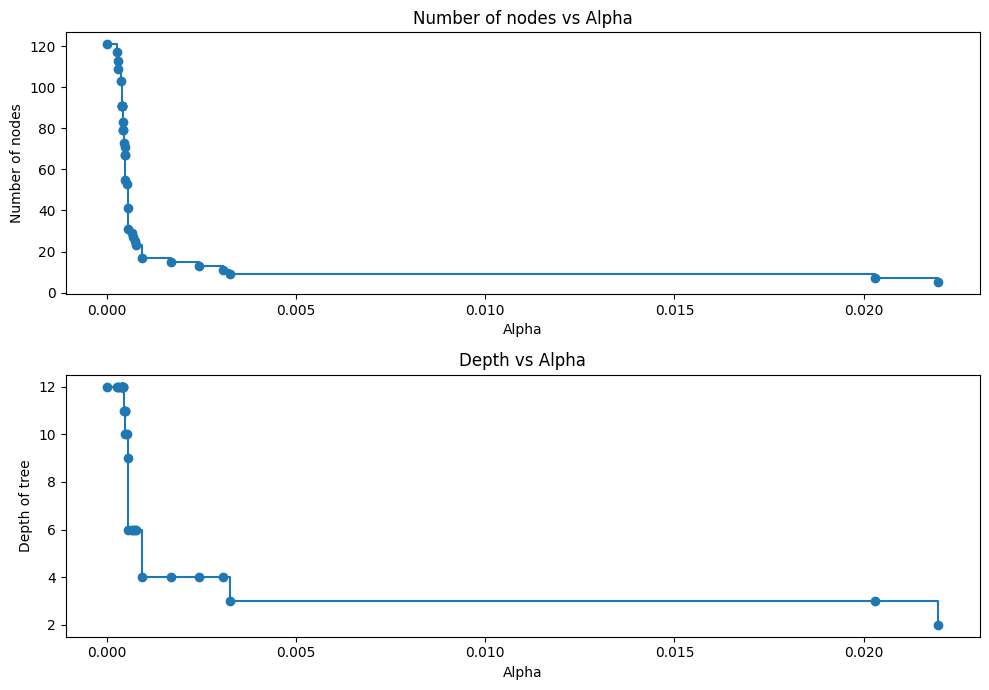

In [58]:
# Remove the last classifier and corresponding ccp_alpha value from the lists

dt_clfs = dt_clfs[:-1] #exclude last value
ccp_alphas = ccp_alphas[:-1] #exclude last value

#Captur enumber of nodes and depth to visualize the graph
# Extract the number of nodes in each tree classifier
node_counts = [dt_clf.tree_.node_count for dt_clf in dt_clfs]

# Extract the maximum depth of each tree classifier
depth = [dt_clf.tree_.max_depth for dt_clf in dt_clfs]

# Create a figure and a set of subplots
fig, ax = plt.subplots(2, 1, figsize=(10, 7))

# Plot the number of nodes versus ccp_alphas on the first subplot
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("Alpha")
ax[0].set_ylabel("Number of nodes")
ax[0].set_title("Number of nodes vs Alpha")

# Plot the depth of tree versus ccp_alphas on the second subplot
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("Alpha")
ax[1].set_ylabel("Depth of tree")
ax[1].set_title("Depth vs Alpha")

# Adjust the layout of the subplots to avoid overlap
fig.tight_layout()

**Number of Nodes vs Alpha**

- This visualization shows how tree size changes with pruning
- As the value of alpha (ccp_alpha) increases, the number of nodes in the tree decreases sharply.
- Too small alpha values suggests the tree is highly complex with many nodes, which increases the risk of overfitting. Beyond a certain alpha(~0.003), the node count stabilizes at a low value, suggesting an overly simplified tree.

**Depth vs Alpha**
- For small alpha values (~0), the tree depth remains high (around 10-12) which causes overfitting
- As alpha increases to the 0.003-0.005 range, the tree depth reduces to around 3-4, indicating a better balance between complexity and generalization.
- At higher alpha values (~0.020), the tree becomes very shallow (depth 2-3), which may lead to underfitting.


Capture the F1 scores on training data

In [59]:
# Initialize an empty list to store F1 scores for training set for each decision tree classifier
train_f1_scores = []

# Iterate through each decision tree classifier in 'dt_clfs'
for dt_clf in dt_clfs:
    # Predict labels for the training set using the current decision tree classifier
    pred_train = dt_clf.predict(X_train)

    # Calculate the F1 score for the training set predictions compared to true labels
    f1_train = f1_score(y_train, pred_train)

    # Append the calculated F1 score to the train_f1_scores list
    train_f1_scores.append(f1_train)

Capture the F1 scores on test data

In [60]:
# Initialize an empty list to store F1 scores for test set for each decision tree classifier
test_f1_scores = []

# Iterate through each decision tree classifier in 'dt_clfs'
for dt_clf in dt_clfs:
    # Predict labels for the test set using the current decision tree classifier
    pred_test = dt_clf.predict(X_test)

    # Calculate the F1 score for the test set predictions compared to true labels
    f1_test = f1_score(y_test, pred_test)

    # Append the calculated F1 score to the test_f1_scores list
    test_f1_scores.append(f1_test)

**Plot testing and training datasets F1 Score vs Alpha**

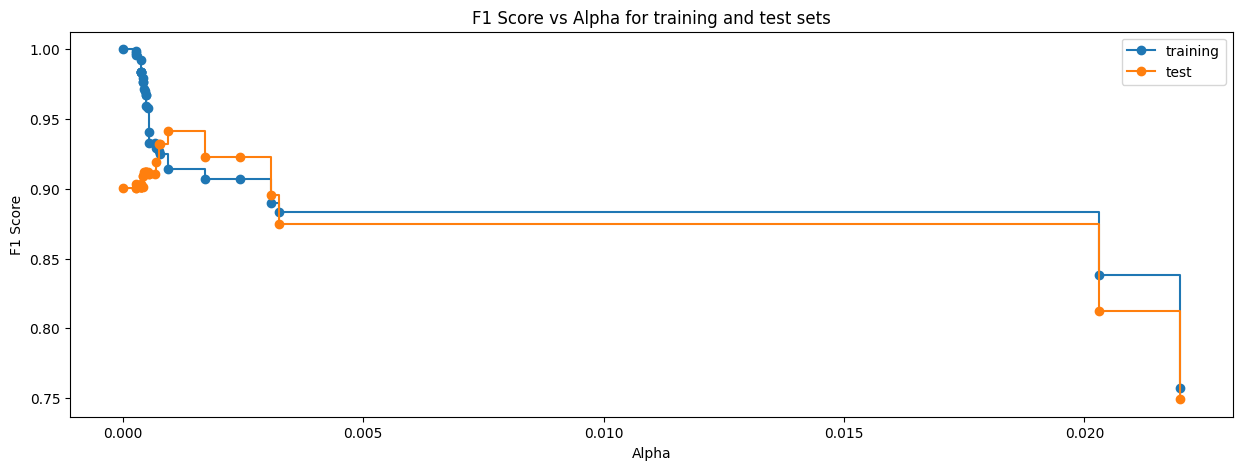

In [61]:
# Create a figure
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("Alpha")  # Set the label for the x-axis
ax.set_ylabel("F1 Score")  # Set the label for the y-axis
ax.set_title("F1 Score vs Alpha for training and test sets")  # Set the title of the plot

# Plot the training F1 scores against alpha, using circles as markers and steps-post style
ax.plot(ccp_alphas, train_f1_scores, marker="o", label="training", drawstyle="steps-post")

# Plot the testing F1 scores against alpha, using circles as markers and steps-post style
ax.plot(ccp_alphas, test_f1_scores, marker="o", label="test", drawstyle="steps-post")

ax.legend();  # Add a legend to the plot

**Observations:**

- At very low values of alpha (~0), the training F1 score is close to 1.0, while the test F1 score is lower, indicating overfitting due to an overly complex decision tree.

- As alpha increases slightly, the training F1 score decreases, while the test F1 score improves and reaches its peak. This suggests that post pruning helps the model generalize better.

- The best model performance on the test set is observed at a range(0.001-0.002), where the gap between training and test F1 scores is minimized.

- Beyond the optimal alpha range, both training and test F1 scores decline, indicating underfitting.

Let's define the effective post pruned model

In [62]:
# Get the index of the best model from test_f1_scores
index_best_model = np.argmax(test_f1_scores)

# now select the decision tree model corresponding to the highest test score
postprune_dtree = dt_clfs[index_best_model]
print(postprune_dtree)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0009328066710555192),
                       random_state=42)


- This confirms the chosen alpha value is 0.00093 (~0.001)

Plot confusion matrix on training data

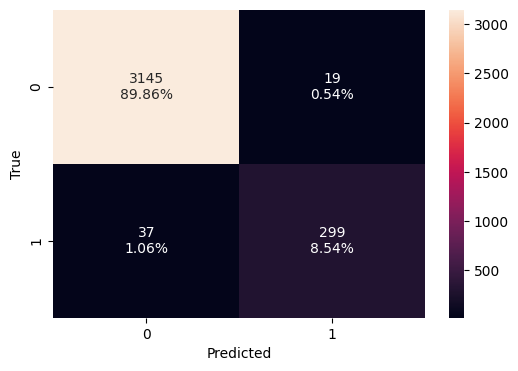

In [63]:
# Plot confusion matrix on training data

plot_confusion_matrix(postprune_dtree, X_train, y_train)

**Observations:**

- The confusion matrix shows 89% true negative, 0.54% false positive, 1.06% false negative and 8.54% true positive on training set

In [64]:
# Calculate the evaluation metrics for training set

postprune_dtree_train_perf = model_performance(
    postprune_dtree, X_train, y_train
)
postprune_dtree_train_perf

,Accuracy,Recall,Precision,F1
0,0.98400,0.88988,0.94025,0.91437


- This model suggests around 98% accuracy for training set, followed with 88.9% recall, 94% precision and 91% F1 score.
- We need highest recall to ensure no false negatives as per the evaluation metrics.

Let's plot confusion matrix for training data

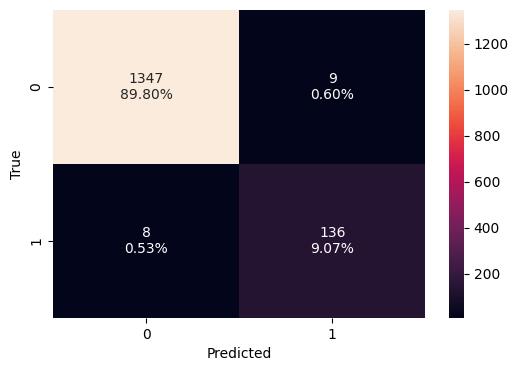

In [65]:
# Plot confusion matrix on test data

plot_confusion_matrix(postprune_dtree, X_test, y_test)

**Observations:**

- The confusion matrix shows 89% true negatives, 0.6% false positive, 0.53% false negative and 9.07% true positive on test set

In [66]:
# Calculate the evaluation metrics for training set

postprune_dtree_test_perf = model_performance(
    postprune_dtree, X_test, y_test
)
postprune_dtree_test_perf

,Accuracy,Recall,Precision,F1
0,0.98867,0.94444,0.93793,0.94118


- This model suggests around 98% accuracy for testing set, followed with 94% recall, 93% precision and 94% F1 score.
- Recall and F1 scores are better with test data which is a very good sign.

#### Visualize the Decision Tree

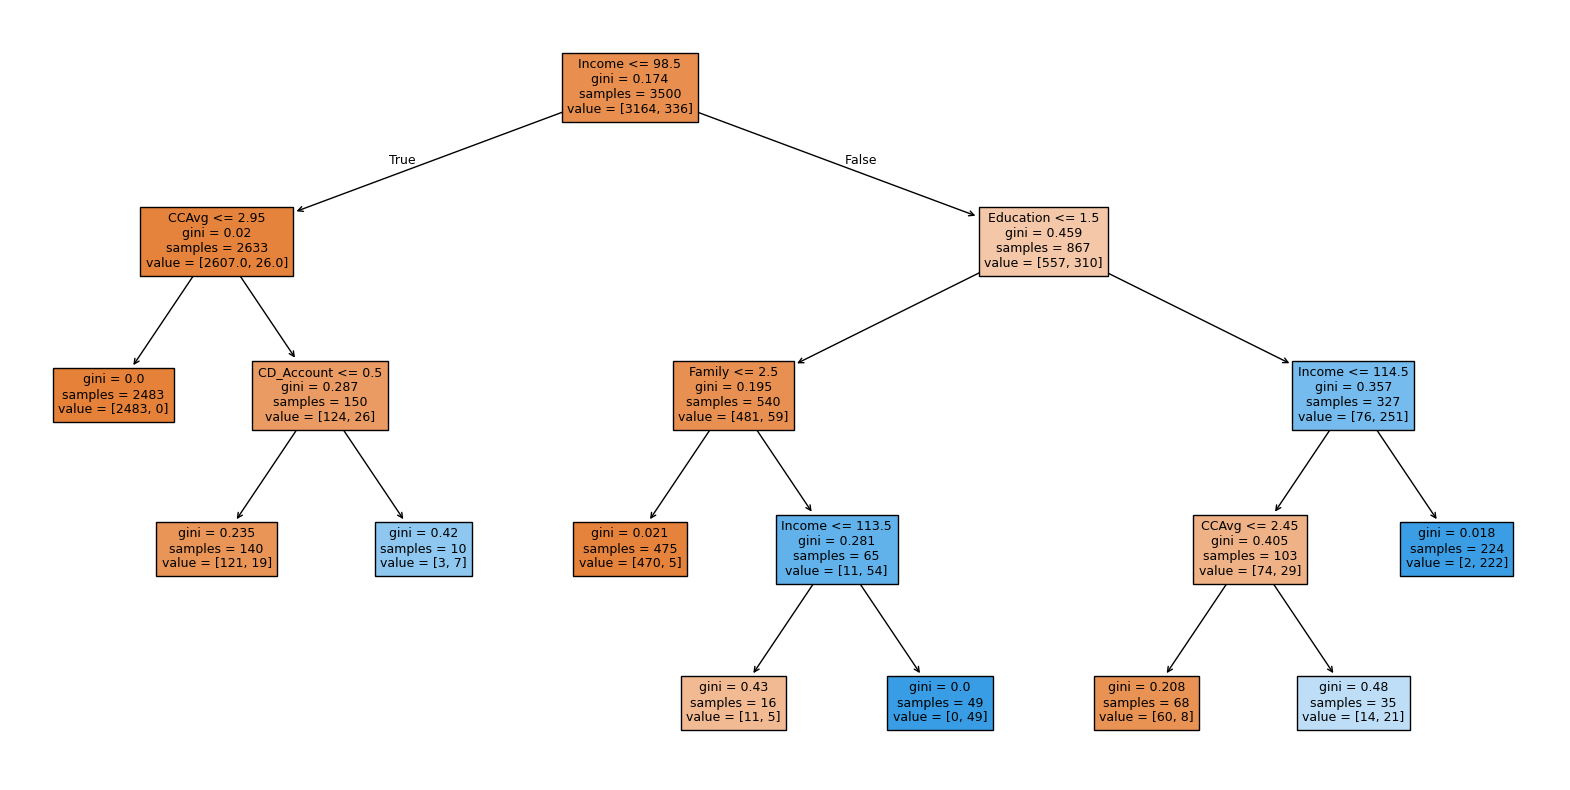

In [67]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 10))

# plotting the decision tree
out = tree.plot_tree(
    postprune_dtree,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

- This is a lot less complex tree, and much better visually
- Nodes with gini ~0 (one example: high income + higher education or high CC spend) represent a certainity of loan acceptance.

Let's print the text form of the decision tree for this model

In [68]:
# Print a text form of decision tree
print(
    tree.export_text(
        postprune_dtree,    # Model - postprune_dtree
        feature_names=feature_names,    # Feature names
        show_weights=True    # Show the weights associated with the model
    )
)

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2483.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- weights: [121.00, 19.00] class: 0
|   |   |--- CD_Account >  0.50
|   |   |   |--- weights: [3.00, 7.00] class: 1
|--- Income >  98.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- weights: [470.00, 5.00] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- Income <= 113.50
|   |   |   |   |--- weights: [11.00, 5.00] class: 0
|   |   |   |--- Income >  113.50
|   |   |   |   |--- weights: [0.00, 49.00] class: 1
|   |--- Education >  1.50
|   |   |--- Income <= 114.50
|   |   |   |--- CCAvg <= 2.45
|   |   |   |   |--- weights: [60.00, 8.00] class: 0
|   |   |   |--- CCAvg >  2.45
|   |   |   |   |--- weights: [14.00, 21.00] class: 1
|   |   |--- Income >  114.50
|   |   |   |--- weights: [2.00, 222.00] class: 1



### Model performance comparison

In [69]:
# Compare training performance for all 3 models

models_train_comp_df = pd.concat(
    [
        plain_dtree_train_perf.T, # default tree
        preprune_dtree_train_perf.T, # prepruned tree
        postprune_dtree_train_perf.T, # post pruned tree
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.00000,0.98457,0.98400
Recall,1.00000,0.89583,0.88988
Precision,1.00000,0.94063,0.94025
F1,1.00000,0.91768,0.91437


- Default decision tree is overfit to training data
- Pre Pruning and Post pruning decision tree have similar scores. The drop from perfect scores suggest that pruning generalised the model well on training data set.

In [70]:
# Compare testing performance for all 3 models

models_test_comp_df = pd.concat(
    [
        plain_dtree_test_perf.T, # default tree
        preprune_dtree_test_perf.T, # prepruned tree
        postprune_dtree_test_perf.T, # post pruned tree
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.98067,0.98733,0.98867
Recall,0.90972,0.94444,0.94444
Precision,0.89116,0.92517,0.93793
F1,0.90034,0.93471,0.94118


**Observations:**

- Default decision tree model doesn't go well with test data.
- Both the pre-pruned and post-pruned decision trees shows generalized performances.
- The post-pruned decision tree has an ~2.93% better performance on the test set than the training set.
- The post-pruned decision tree has better F1 score on testing set.
- The pre-pruned decision tree has almost same performance on F1 score and accuracy for both training and test data set
- There an improvement in Recall, but drop in precision (0.94 to 0.92) for pre-pruning model for training and test data sets
- Post Pruning model achieves the strongest balance on the test set, with the highest F1-score (0.94118), indicating robust performance on the imbalanced positive class without overfitting. This suggests better generalization for deployment.
- We'll move ahead with the ***post-pruned decision tree*** as our final model.


#### Decision Rules

Based on the final post-pruned Decision Tree model, the following key decision rules can be derived:

1. Higher income and education level

```
if income > 98.5 (thousand dollars)
   and if education is > 1.5 (i.e., higher than undergraduate)
       and if income is more than 114.50
           then the customer is likely to accept the personal loan
```

2. Higher income, with good family size

```
if income > 98.5 (thousand dollars)
   and if education is < 1.5 (i.e., undergraduate/graduate)
       and if family is more than 2.5 (Around 3 people in family)
          and if income is more than 113.50
             then the customer is likely to accept the personal loan
```

3. Average income, with good CC Average and CD Account

```
if income <= 98.5 (thousand dollars)
   and if CCAvg is > 2.95 (i.e., average spending in thousand dollars)
       and if CD_account is more than 0.5 (Customer with deposit account)
           then the customer is likely to accept the personal loan
```

These are few decision rules that can be derived from the post-pruned decision tree, and it signifies Income, Education, Family, CCAvg, CD_account are important features for the model

### Feature Importance

Post pruned tree is our final model, let's see the overview of the importance of features used in building a model

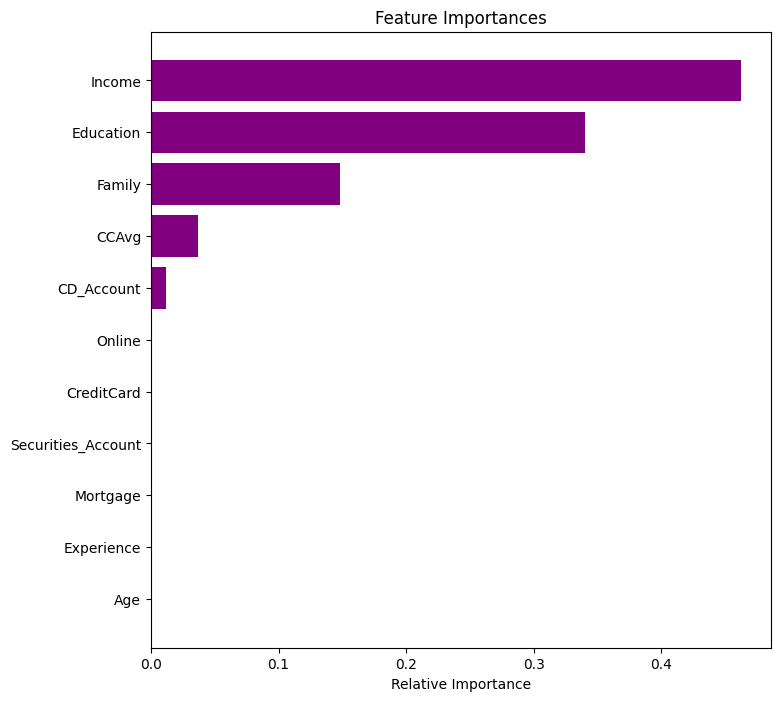

In [71]:
# importance of features in the tree building for post pruning

importances = postprune_dtree.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="purple", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- Income and Education are the most influential attributes in determining personal loan acceptance
- Family and CCAvg are the next best attributes to consider
- This feature importance metrics confirms the decision rules for the model

### Actionable Insights and Recommendations









**Insights:**

Based on the post-pruned decision tree model, below are the key takeaways to AllLife Bank's marketing team:

1. Income is the key differentiator
    - Customers with higher income levels consistently show a greater likelihood of accepting personal loan offers.
    - Specifically customers with Income more than 114K accept loans at 85% probability rate.
    - Prioritize this segment for the initial pilot campaign rollout to maximize early conversion.

2. Professional Status (Education)
    - Education degree/level acts as a strong indicator with customers holding graduate or professional degrees being more responsive to loan campaigns.
    - They probably show 3 times higher acceptance rate

3. Engagement
    - Credit card spending behavior (CCAvg) differentiates high-potential customers, indicates the stronger financial engagement and open to credit products.
    - With CCAvg more than 2.5 suggests 70% probability of acceptors in middle income brackets.

4. Family Size
    - Large families(3+) increase loan acceptance by two times if the mortgage is low.
    - Large families tend to show a higher tendency to accept personal loans, likely due to increased financial needs such as education, housing, or lifestyle expenses.

All these factors drive ~90% of decisions and could improve the 9% baseline target sales to 15-20%

**Recommendations:**

To launch an efficient, data driven personal loan push, aim for a segmented digital campaign targeting around 35% of the customer base (high potential segments) over 3 months period

1. Adopt a "Tier" based targeting strategy

    - **Tier 1 (High Priority):**
      - Focus the majority of the marketing budget on customers who fall into the category of High Income + advanced education. This segment has the highest conversion probability.
      - Send personalised emails to the focussed group.
        * Ex: Upgrade your lifestyle with a low rate for professionals like you.

    - **Tier 2 (Cross Sell):**
      - Target customers with high credit card spending (CCAvg). These users are already comfortable with debt/credit products.
      - For Mid income and high CCAvg, offer pre-approval loans via app/email notifications.
        * Ex: Based on your spending, you are prequalified for \$15k at 5% interest rate.

    - **Family centric offers:**
      - For large families, consider framing the loan as a tool for family milestones.
      - Use relation manager led or personalized digital outreach for family segments to build trust and improve response rates.
      - Bundle the promotion with family protection or few add-ons to lift the acceptance rate.
        * Ex: Upgrade your home (or) Finance your child's education

2. **Messaging:**
    - **Integrate with CRM:** Leverage model's decision rules for personalization, and integrate to CRM for auto-segmentation and send the offers.
    - **Value Proposition:** Since the target audience is wealthier and more educated, make sure to focus on speed, exclusivity and value

3. **Budget:**
    - Make sure to allocate budget on digital campaigns (ads, linkedIn recommendations, emails etc).
    - Start with a pilot customer base, and make sure transparency is provided to the customers to build trust and comply with the regulations.

4. **Cost Saving:**
    - Avoid aggressively targeting low-income customers with smaller families, as this segment shows lower loan conversion probability and may lead to inefficient spend.

#### Conclusion

- The model identifies that high-income customers (\$100k+) with moderate credit card spending are our prime targets.

- The recommended strategy for the marketing team is to focus on high-income, well-educated customers with higher average credit card spending, while delivering family-aware messaging to maximize the campaign's impact.

### Appendix

- City is a high cardinality feature. A quick experiment is conducted to check the importance of City (included top 5 cities with good loan acceptance rate)
- Top 5 cities are included in the data set with One-Hot encoding for this experiment

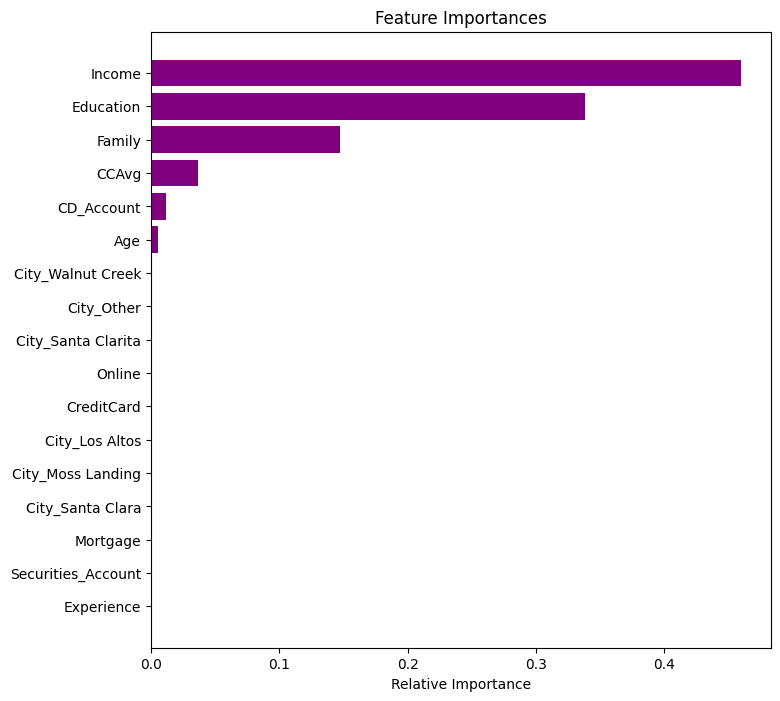

- Based on this feature importance chart, it is evident that City feature is not much considered by the decision tree model, as all the cities show negligible importance
- This also confirms our EDA on City/ZipCode feature